In [1]:
import glob
import os

import decoupler as dc
import matplotlib.pyplot as plt
import pandas as pd
import pertpy as pt
import scanpy as sc
import seaborn as sns

In [2]:
INPUT_DIR = "inputs"

# Omentum

In [3]:
adata = sc.read_h5ad(os.path.join(INPUT_DIR, "anndatas", 'omentum_reannotated_finely.h5ad'))

In [22]:
with pd.option_context('display.max_rows', 200):
    print(adata.obs.value_counts(["cell_type", "participant"]).sort_index())

cell_type       participant        
B cells         Omentum_Healthy_0        91
                Omentum_Healthy_1        12
                Omentum_Healthy_2       135
                Omentum_Healthy_3        26
                Omentum_Healthy_4         8
                Omentum_Unhealthy_0      24
                Omentum_Unhealthy_1       5
                Omentum_Unhealthy_2      16
                Omentum_Unhealthy_3      52
                Omentum_Unhealthy_4       5
ECs             Omentum_Healthy_0       150
                Omentum_Healthy_1       122
                Omentum_Healthy_2       119
                Omentum_Healthy_3       166
                Omentum_Healthy_4        33
                Omentum_Unhealthy_0      42
                Omentum_Unhealthy_1      48
                Omentum_Unhealthy_2      52
                Omentum_Unhealthy_3      47
                Omentum_Unhealthy_4      91
FAPs            Omentum_Healthy_0      1133
                Omentum_Healthy_1      1

In [370]:
with pd.option_context('display.max_rows', 200):
    print(adata.obs.value_counts(["cell_type_", "cell_type2_"]).sort_index())

cell_type_      cell_type2_         
B_cells         B_cells                  374
ECs             LECs                     163
                VECs                     707
FAPs            FAPs                    6787
IGFBP2_cells    IGFBP2                   587
Mesothelial     MMT_cells                 37
                Mesothelial_cells       4972
Myeloid_cells   Macrophages              811
                Mast_cells?              101
                Monocytes                397
                Neutrophils              858
                cDCs                     596
                pDCs                     118
Myofibroblasts  Myofibroblasts           697
NK_cells        mNK1_cells               410
                mNK2_cell                373
                mNK3_cells               564
Plasma_cells    Plasma_cells              61
Pre-adipocytes  Pre-adipocytes          1297
T_cells         CD4_T_cells             2210
                CD8_TRM                  887
                CD

In [6]:
adata.obs.columns

Index(['status', 'assignment', 'singlet_posterior', 'doublet_posterior',
       'log_prob_singleton', 'log_prob_doublet', 'cluster0', 'cluster1',
       'cluster2', 'cluster3', 'cluster4', 'sample_name', 'disease', 'tissue',
       'cohort', 'participant', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden',
       'leiden_res_0.02', 'leiden_res_0.20', 'leiden_res_0.30',
       'leiden_res_0.40', 'leiden_res_0.50', 'leiden_res_0.60',
       'leiden_res_1.00', 'cell_type', 'cd45', 'cell_type1', 'scrublet_score',
       'scrublet_call', 'lib_name', 'sex'],
      dtype='object')

In [4]:
adata.obs["cell_type_"] = [ct.replace(" ", "_") for ct in adata.obs["cell_type"]]
adata.obs["cell_type_"] = [ct.replace("+", "") for ct in adata.obs["cell_type_"]]

adata.obs["cell_type1_"] = [ct.replace(" ", "_") for ct in adata.obs["cell_type1"]]
adata.obs["cell_type1_"] = [ct.replace("+", "") for ct in adata.obs["cell_type1_"]]

adata.obs.cell_type1_ = adata.obs.cell_type1_.astype("str").str.replace("-", "_")
adata.obs.cell_type_ = adata.obs.cell_type_.astype("str").str.replace("-", "_")

adata.obs.cell_type1_ = adata.obs.cell_type1_.astype("str").str.replace("?", "_")
adata.obs.cell_type_ = adata.obs.cell_type_.astype("str").str.replace("?", "_")

adata.obs["participant"] = adata.obs["participant"].astype("category")
adata.obs["cohort"] = adata.obs["cohort"].astype("category")
adata.obs["sex"] = adata.obs["sex"].astype("category")
adata.obs["cell_type_"] = adata.obs["cell_type_"].astype("category")
adata.obs["cell_type1_"] = adata.obs["cell_type1_"].astype("category")

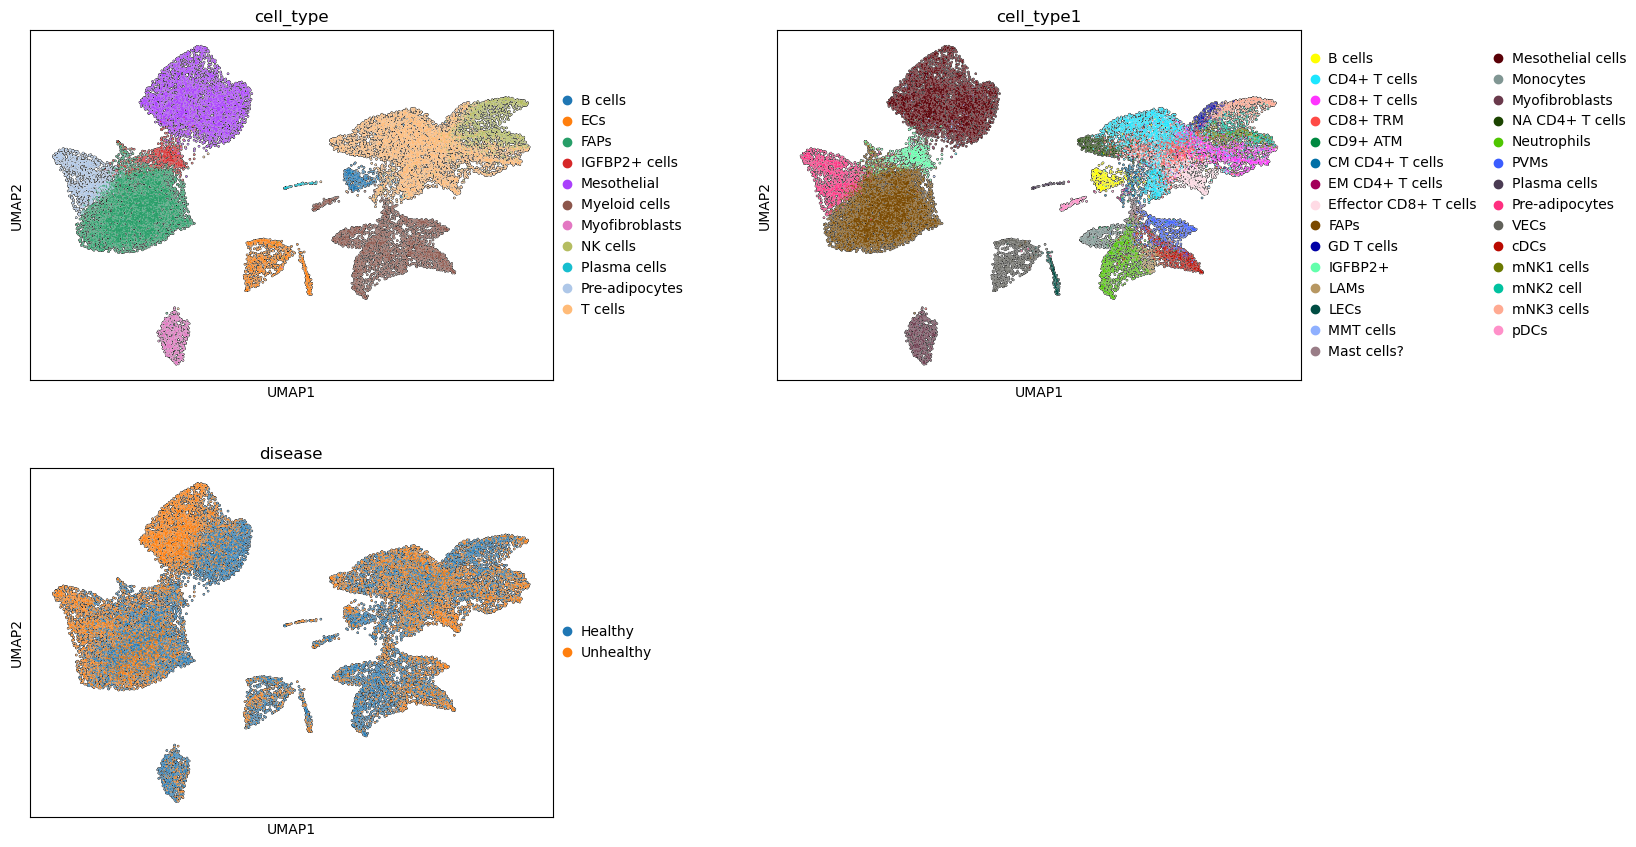

In [5]:
fig = sc.pl.umap(
    adata,
    color=["cell_type", "cell_type1", "disease"],
    ncols=2,
    # legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2,
    return_fig=True,
    wspace=0.3
    # ax=ax
)

In [5]:
cell_type_col = "cell_type2_"

adata.obs[cell_type_col] = adata.obs["cell_type1_"]

In [6]:
cell_types_to_rename = {
    "CD9_ATM": "Macrophages",
    "LAMs": "Macrophages",
    "PVMs": "Macrophages",
}
for cell_type, new_cell_type in cell_types_to_rename.items():
    if new_cell_type not in adata.obs[cell_type_col].cat.categories:
        adata.obs[cell_type_col] = adata.obs[cell_type_col].cat.add_categories(
            [new_cell_type]
        )
    adata.obs.loc[adata.obs[cell_type_col] == cell_type, cell_type_col] = (
        new_cell_type
    )

In [7]:
participant_col = "common_participant"
adata.obs[participant_col] = adata.obs.participant.str.replace("Omentum_", "")

In [488]:
adata.var

,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,means,variances,residual_variances,highly_variable_rank,highly_variable_nbatches,highly_variable_intersection,highly_variable
AL627309.1,False,False,False,41,0.001280,0.001279,99.875072,42.0,3.761200,41,0.001123,0.001122,0.881984,NaN,0,False,False
AL627309.3,False,False,False,4,0.000122,0.000122,99.987812,4.0,1.609438,4,0.000077,0.000077,0.160854,NaN,0,False,False
AL627309.5,False,False,False,172,0.005271,0.005257,99.475913,173.0,5.159055,172,0.004568,0.004548,1.238005,NaN,0,False,False
AP006222.2,False,False,False,3,0.000091,0.000091,99.990859,3.0,1.386294,3,0.000116,0.000116,0.100389,NaN,0,False,False
LINC01409,False,False,False,845,0.027240,0.026876,97.425272,894.0,6.796824,845,0.026945,0.029473,1.228264,NaN,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AL592183.1,False,False,False,1566,0.051525,0.050242,95.228374,1691.0,7.433667,1566,0.051452,0.056550,1.165134,NaN,0,False,False
AC240274.1,False,False,False,430,0.013742,0.013648,98.689783,451.0,6.113682,430,0.013666,0.014874,1.169597,NaN,0,False,False
AC004556.3,False,False,False,504,0.017094,0.016949,98.464304,561.0,6.331502,504,0.017654,0.020440,0.414735,NaN,0,False,False
AC007325.4,False,False,False,313,0.009994,0.009945,99.046284,328.0,5.796058,313,0.010376,0.011275,1.015282,NaN,0,False,False


In [490]:
adata.layers["counts"].sum(axis=1)

matrix([[ 2202.],
        [ 7881.],
        [ 9092.],
        ...,
        [15208.],
        [ 9088.],
        [ 5415.]], shape=(25830, 1), dtype=float32)

In [493]:
import anndata
anndata.settings.allow_write_nullable_strings = True
adata.write_h5ad(os.path.join(INPUT_DIR, "anndatas", 'omentum_reannotated_finely.h5ad'))

In [495]:
adata.var.drop(adata.var.columns, axis=1, inplace=True)

In [498]:
adata.obs.drop(adata.obs.columns[:-5], axis=1, inplace=True)

In [501]:
adata.obs["cohort"] = adata.obs[participant_col].str.split("_", expand=True).iloc[:,0]

In [502]:
adata.obs.value_counts(["cohort", participant_col])

cohort     common_participant
Healthy    Healthy_1             3769
           Healthy_2             3722
           Healthy_0             3563
           Healthy_3             2790
Unhealthy  Unhealthy_1           2562
           Unhealthy_2           2342
           Unhealthy_3           2240
           Unhealthy_0           2124
           Unhealthy_4           1988
Healthy    Healthy_4              730
Name: count, dtype: int64

In [505]:
adata.uns = {}

In [25]:
adata_orig = sc.read_10x_mtx("/Users/willtrim/Documents/projs/Wills_analysis/obesity_scRNAseq/inputs/BRI-1456/filtered_feature_bc_matrix")

In [522]:
adata.var["gene_id"] = adata_orig.var.loc[adata.var_names, "gene_ids"].values

In [524]:
adata.write_h5ad(os.path.join(INPUT_DIR, "anndatas", 'omentum_reannotated_finely_truncated.h5ad'))

In [509]:
sex_genes = {
  "XIST": "ENSG00000229807",  # high in females
  "RPS4Y1": "ENSG00000129824",  # high in males
  "DDX3Y": "ENSG00000067048",  # high in males
  "USP9Y": "ENSG00000114374"   # high in males
}

In [512]:
adata.var.loc[adata.var_names.isin(sex_genes.keys()),:]

""
XIST
RPS4Y1
USP9Y
DDX3Y


In [514]:
adata.obs

,sex,cell_type_,cell_type1_,cell_type2_,common_participant,cohort
AAACCCAAGAACTTCC-1_Healthy,M,ECs,VECs,VECs,Healthy_3,Healthy
AAACCCAAGATGTTGA-1_Healthy,M,Myofibroblasts,Myofibroblasts,Myofibroblasts,Healthy_3,Healthy
AAACCCAAGCCAAGGT-1_Healthy,M,FAPs,FAPs,FAPs,Healthy_3,Healthy
AAACCCAAGCTATCCA-1_Healthy,M,Myeloid_cells,PVMs,Macrophages,Healthy_3,Healthy
AAACCCAAGTTGCCTA-1_Healthy,F,Myeloid_cells,PVMs,Macrophages,Healthy_1,Healthy
...,...,...,...,...,...,...
TTTGTTGCACAATGCT-1_Unhealthy,F,Mesothelial,Mesothelial_cells,Mesothelial_cells,Unhealthy_4,Unhealthy
TTTGTTGGTGACTGAG-1_Unhealthy,F,FAPs,FAPs,FAPs,Unhealthy_4,Unhealthy
TTTGTTGGTTAGGACG-1_Unhealthy,F,FAPs,FAPs,FAPs,Unhealthy_0,Unhealthy
TTTGTTGTCGAGTTGT-1_Unhealthy,F,Pre_adipocytes,Pre_adipocytes,Pre_adipocytes,Unhealthy_0,Unhealthy


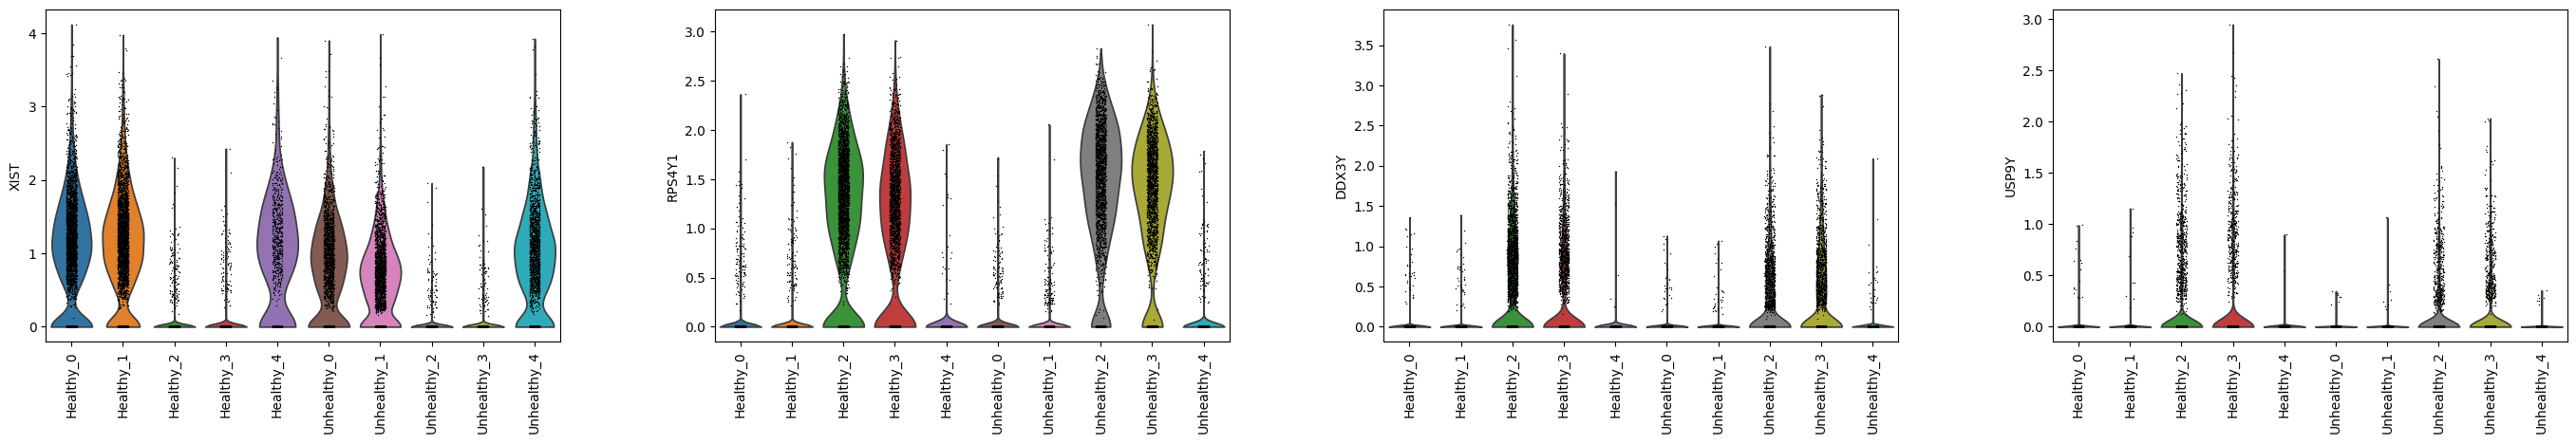

In [519]:
sc.pl.violin(adata, sex_genes.keys(), groupby=participant_col, rotation=90)

## Pseudobulk

In [355]:
NUM_OF_CELL_PER_DONOR = 3
import random


def aggregate_and_filter(
    adata,
    cell_identity,
    donor_key="participant",
    condition_key="cohort",
    cell_identity_key="cell_type_",
    obs_to_keep=None,  # which additional metadata to keep, e.g. gender, age, etc.
    replicates_per_patient=1,
):
    # subset adata to the given cell identity
    if obs_to_keep is None:
        obs_to_keep = []
    adata_cell_pop = adata[adata.obs[cell_identity_key] == cell_identity].copy()
    # check which donors to keep according to the number of cells specified with NUM_OF_CELL_PER_DONOR
    size_by_donor = adata_cell_pop.obs.groupby([donor_key], observed=False).size()
    donors_to_drop = [
        donor
        for donor in size_by_donor.index
        if size_by_donor[donor] <= NUM_OF_CELL_PER_DONOR
    ]
    if len(donors_to_drop) > 0:
        print("Dropping the following samples:")
        print(donors_to_drop)
    df = pd.DataFrame(columns=[*adata_cell_pop.var_names, *obs_to_keep])

    adata_cell_pop.obs[donor_key] = adata_cell_pop.obs[donor_key].astype("category")
    for i, donor in enumerate(donors := adata_cell_pop.obs[donor_key].cat.categories):
        print(f"\tProcessing donor {i+1} out of {len(donors)}...", end="\r")
        if donor not in donors_to_drop:
            adata_donor = adata_cell_pop[adata_cell_pop.obs[donor_key] == donor]
            # # create replicates for each donor
            # indices = list(adata_donor.obs_names)
            # random.shuffle(indices)
            # indices = np.array_split(np.array(indices), replicates_per_patient)
            # for i, rep_idx in enumerate(indices):
            adata_replicate = adata_donor #[rep_idx]
            # specify how to aggregate: sum gene expression for each gene for each donor and also keep the condition information
            agg_dict = dict.fromkeys(adata_replicate.var_names, "sum")
            for obs in obs_to_keep:
                agg_dict[obs] = "first"
            # create a df with all genes, donor and condition info
            df_donor = pd.DataFrame(adata_replicate.X.toarray())
            df_donor.index = adata_replicate.obs_names
            df_donor.columns = adata_replicate.var_names
            df_donor = df_donor.join(adata_replicate.obs[obs_to_keep])
            # aggregate
            df_donor = df_donor.groupby(donor_key, observed=True).agg(agg_dict)
            df_donor[donor_key] = donor
            df.loc[f"donor_{donor}"] = df_donor.loc[donor]
    print("\n")
    # create AnnData object from the df
    adata_cell_pop = sc.AnnData(
        df[adata_cell_pop.var_names], obs=df.drop(columns=adata_cell_pop.var_names)
    )
    return adata_cell_pop

In [351]:
obs_to_keep = ["participant", "cell_type_", "cell_type1_", "cell_type2_", "cohort", "sex"]
adata.X = adata.layers["counts"].copy()

In [353]:
cell_type_col = "cell_type2_"

In [359]:
adata.obs[cell_type_col] = adata.obs[cell_type_col].cat.remove_categories(["CD9_ATM", "LAMs", "PVMs"])

In [361]:
adata.obs.value_counts(cell_type_col)

cell_type2_
FAPs                    6787
Mesothelial_cells       4972
CD4_T_cells             2210
Pre-adipocytes          1297
Effector_CD8_T_cells     957
CD8_T_cells              943
CD8_TRM                  887
Neutrophils              858
Macrophages              811
VECs                     707
Myofibroblasts           697
cDCs                     596
IGFBP2                   587
mNK3_cells               564
mNK1_cells               410
Monocytes                397
NA_CD4_T_cells           392
B_cells                  374
mNK2_cell                373
CM_CD4_T_cells           244
GD_T_cells               198
LECs                     163
pDCs                     118
Mast_cells?              101
EM_CD4_T_cells            89
Plasma_cells              61
MMT_cells                 37
Name: count, dtype: int64

In [362]:
adatas_pb = []

for i, cell_type in enumerate(adata.obs[cell_type_col].cat.categories):
    print(
        f'Processing {cell_type} ({i + 1} out of {len(adata.obs[cell_type_col].cat.categories)})...'
    )
    adata_cell_type = aggregate_and_filter(adata, cell_type, obs_to_keep=obs_to_keep, cell_identity_key=cell_type_col)
    adatas_pb.append(adata_cell_type)

Processing B_cells (1 out of 27)...
	Processing donor 10 out of 10...

Processing CD4_T_cells (2 out of 27)...
	Processing donor 10 out of 10...

Processing CD8_TRM (3 out of 27)...
	Processing donor 10 out of 10...

Processing CD8_T_cells (4 out of 27)...
	Processing donor 10 out of 10...

Processing CM_CD4_T_cells (5 out of 27)...
	Processing donor 10 out of 10...

Processing EM_CD4_T_cells (6 out of 27)...
	Processing donor 9 out of 9...

Processing Effector_CD8_T_cells (7 out of 27)...
Dropping the following samples:
['Omentum_Healthy_1']
	Processing donor 9 out of 9...

Processing FAPs (8 out of 27)...
	Processing donor 10 out of 10...

Processing GD_T_cells (9 out of 27)...
Dropping the following samples:
['Omentum_Unhealthy_1', 'Omentum_Unhealthy_3']
	Processing donor 10 out of 10...

Processing IGFBP2 (10 out of 27)...
Dropping the following samples:
['Omentum_Unhealthy_0']
	Processing donor 9 out of 9...

Processing LECs (11 out of 27)...
Dropping the following samples:
['Omen

In [363]:
import anndata
adata_pb = anndata.concat(adatas_pb, )

In [364]:
adata_pb.obs_names = adata_pb.obs_names.astype(str) + "_" + adata_pb.obs[cell_type_col].astype(str)

In [14]:
import numpy as np
# adata_pb.X = adata_pb.X.astype(np.float32)

In [15]:
np.isnan(adata_pb.X).any(), np.isinf(adata_pb.X).any()

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [365]:
adata_pb.X.sum(axis=0)

array([np.float32(29.0), np.float32(2.0), np.float32(118.0), ...,
       np.float32(453.0), np.float32(268.0), np.float32(2.0)],
      shape=(26144,), dtype=object)

In [366]:
adata_pb.X.sum(axis=1)

array([np.float32(359576.0), 48257.0, 503079.0, 114570.0, 33601.0,
       117740.0, 28648.0, 80924.0, 270180.0, 28165.0,
       np.float32(1178562.0), 1060492.0, 985397.0, 932528.0, 306509.0,
       761811.0, 953741.0, 252691.0, 1244923.0, 470309.0,
       np.float32(308053.0), 159593.0, 264881.0, 442546.0, 66900.0,
       328702.0, 310874.0, 332078.0, 265442.0, 27447.0,
       np.float32(273223.0), 189768.0, 266351.0, 544291.0, 70796.0,
       320475.0, 1072719.0, 123212.0, 337922.0, 90886.0,
       np.float32(89938.0), 174884.0, 158350.0, 148743.0, 26088.0,
       54586.0, 37321.0, 56806.0, 24023.0, 92796.0, np.float32(84198.0),
       167207.0, 74376.0, 49139.0, 113969.0, 150278.0, 75494.0, 166529.0,
       61936.0, np.float32(102468.0), 106895.0, 516805.0, 41814.0,
       50287.0, 2306331.0, 547866.0, 483607.0, np.float32(6614241.0),
       7958525.0, 5305516.0, 3453474.0, 818409.0, 4448100.0, 3414186.0,
       920133.0, 2356668.0, 6541725.0, np.float32(231320.0), 14997.0,
       1

In [367]:
adata_pb

AnnData object with n_obs × n_vars = 247 × 26144
    obs: 'participant', 'cell_type_', 'cell_type1_', 'cell_type2_', 'cohort', 'sex'

In [19]:
sc.pp.filter_genes(adata, min_cells=1) 

In [20]:
adata_pb

AnnData object with n_obs × n_vars = 96 × 26158
    obs: 'participant', 'cell_type_', 'cell_type1_', 'cohort', 'sex'

In [368]:
adata_pb.X = adata_pb.X.astype(np.float32)

In [369]:
adata_pb.write_h5ad(os.path.join(INPUT_DIR, "anndatas", 'omentum_reannotated_finely_pb_cell_type2_.h5ad'))

... storing 'participant' as categorical
... storing 'cell_type_' as categorical
... storing 'cell_type1_' as categorical
... storing 'cell_type2_' as categorical
... storing 'cohort' as categorical
... storing 'sex' as categorical


In [328]:
os.path.join(INPUT_DIR, "anndatas", 'omentum_reannotated_finely_pb.h5ad')

'inputs/anndatas/omentum_reannotated_finely_pb.h5ad'

In [38]:
adata_pb.layers['counts'] = adata_pb.X.copy()

In [35]:
# import decoupler as dc

# adata_pb = dc.pp.swap_layer(adata_pb, key="counts", X_key="X")

In [39]:
adata_pb.X.max()

719471.0

In [28]:
a = adata_pb.X

In [29]:
ind = np.unravel_index(np.argmax(a, axis=None), a.shape)
a[ind]

np.float64(13.022465967328728)

In [30]:
ind

(np.int64(74), np.int64(3254))

In [31]:
adata_pb.obs_names[ind[0]], adata_pb.var_names[ind[1]]

('donor_Omentum_Healthy_0_Plasma_cells', 'IGKC')

In [40]:
sc.pp.normalize_total(adata_pb, target_sum=1e6)
sc.pp.log1p(adata_pb)

In [41]:
# sc.pp.normalize_total(adata_pb, target_sum=1e6)
# sc.pp.log1p(adata_pb)
sc.pp.scale(adata_pb, max_value=10)
sc.pp.pca(adata_pb, )

In [42]:
adata_pb.X

array([[-0.42550183, -0.13617177,  1.85993433, ..., -0.50353404,
        -0.80433513, -0.12275109],
       [-0.42550183, -0.13617177, -0.67213158, ..., -0.50353404,
        -0.80433513, -0.12275109],
       [-0.42550183, -0.13617177, -0.67213158, ..., -0.50353404,
        -0.80433513, -0.12275109],
       ...,
       [ 2.47441303, -0.13617177,  0.23338135, ...,  1.96385878,
         0.19536707, -0.12275109],
       [-0.42550183, -0.13617177,  0.74904513, ..., -0.50353404,
         0.50964906, -0.12275109],
       [-0.42550183, -0.13617177, -0.67213158, ..., -0.50353404,
        -0.80433513, -0.12275109]], shape=(96, 26158))

In [43]:
import numpy as np

adata_pb.obs["lib_size"] = np.sum(adata_pb.layers["counts"], axis=1).astype(np.float32)
adata_pb.obs["log_lib_size"] = np.log(adata_pb.obs["lib_size"])

In [44]:
adata_pb.obs

,participant,cell_type_,cell_type1_,cohort,sex,lib_size,log_lib_size
donor_Omentum_Healthy_0_B_cells,Omentum_Healthy_0,B_cells,B_cells,Healthy,F,359576.0,12.792681
donor_Omentum_Healthy_1_B_cells,Omentum_Healthy_1,B_cells,B_cells,Healthy,F,48257.0,10.784296
donor_Omentum_Healthy_2_B_cells,Omentum_Healthy_2,B_cells,B_cells,Healthy,M,503079.0,13.128503
donor_Omentum_Healthy_3_B_cells,Omentum_Healthy_3,B_cells,B_cells,Healthy,M,114570.0,11.648941
donor_Omentum_Unhealthy_0_B_cells,Omentum_Unhealthy_0,B_cells,B_cells,Unhealthy,F,117740.0,11.676234
...,...,...,...,...,...,...,...
donor_Omentum_Unhealthy_0_T_cells,Omentum_Unhealthy_0,T_cells,CD4_T_cells,Unhealthy,F,2390105.0,14.686848
donor_Omentum_Unhealthy_1_T_cells,Omentum_Unhealthy_1,T_cells,CD8_T_cells,Unhealthy,F,2580499.0,14.763494
donor_Omentum_Unhealthy_2_T_cells,Omentum_Unhealthy_2,T_cells,Effector_CD8_T_cells,Unhealthy,M,3283896.0,15.004541
donor_Omentum_Unhealthy_3_T_cells,Omentum_Unhealthy_3,T_cells,CD4_T_cells,Unhealthy,M,2703706.0,14.810134


... storing 'participant' as categorical
... storing 'cell_type_' as categorical
... storing 'cell_type1_' as categorical
... storing 'cohort' as categorical
... storing 'sex' as categorical


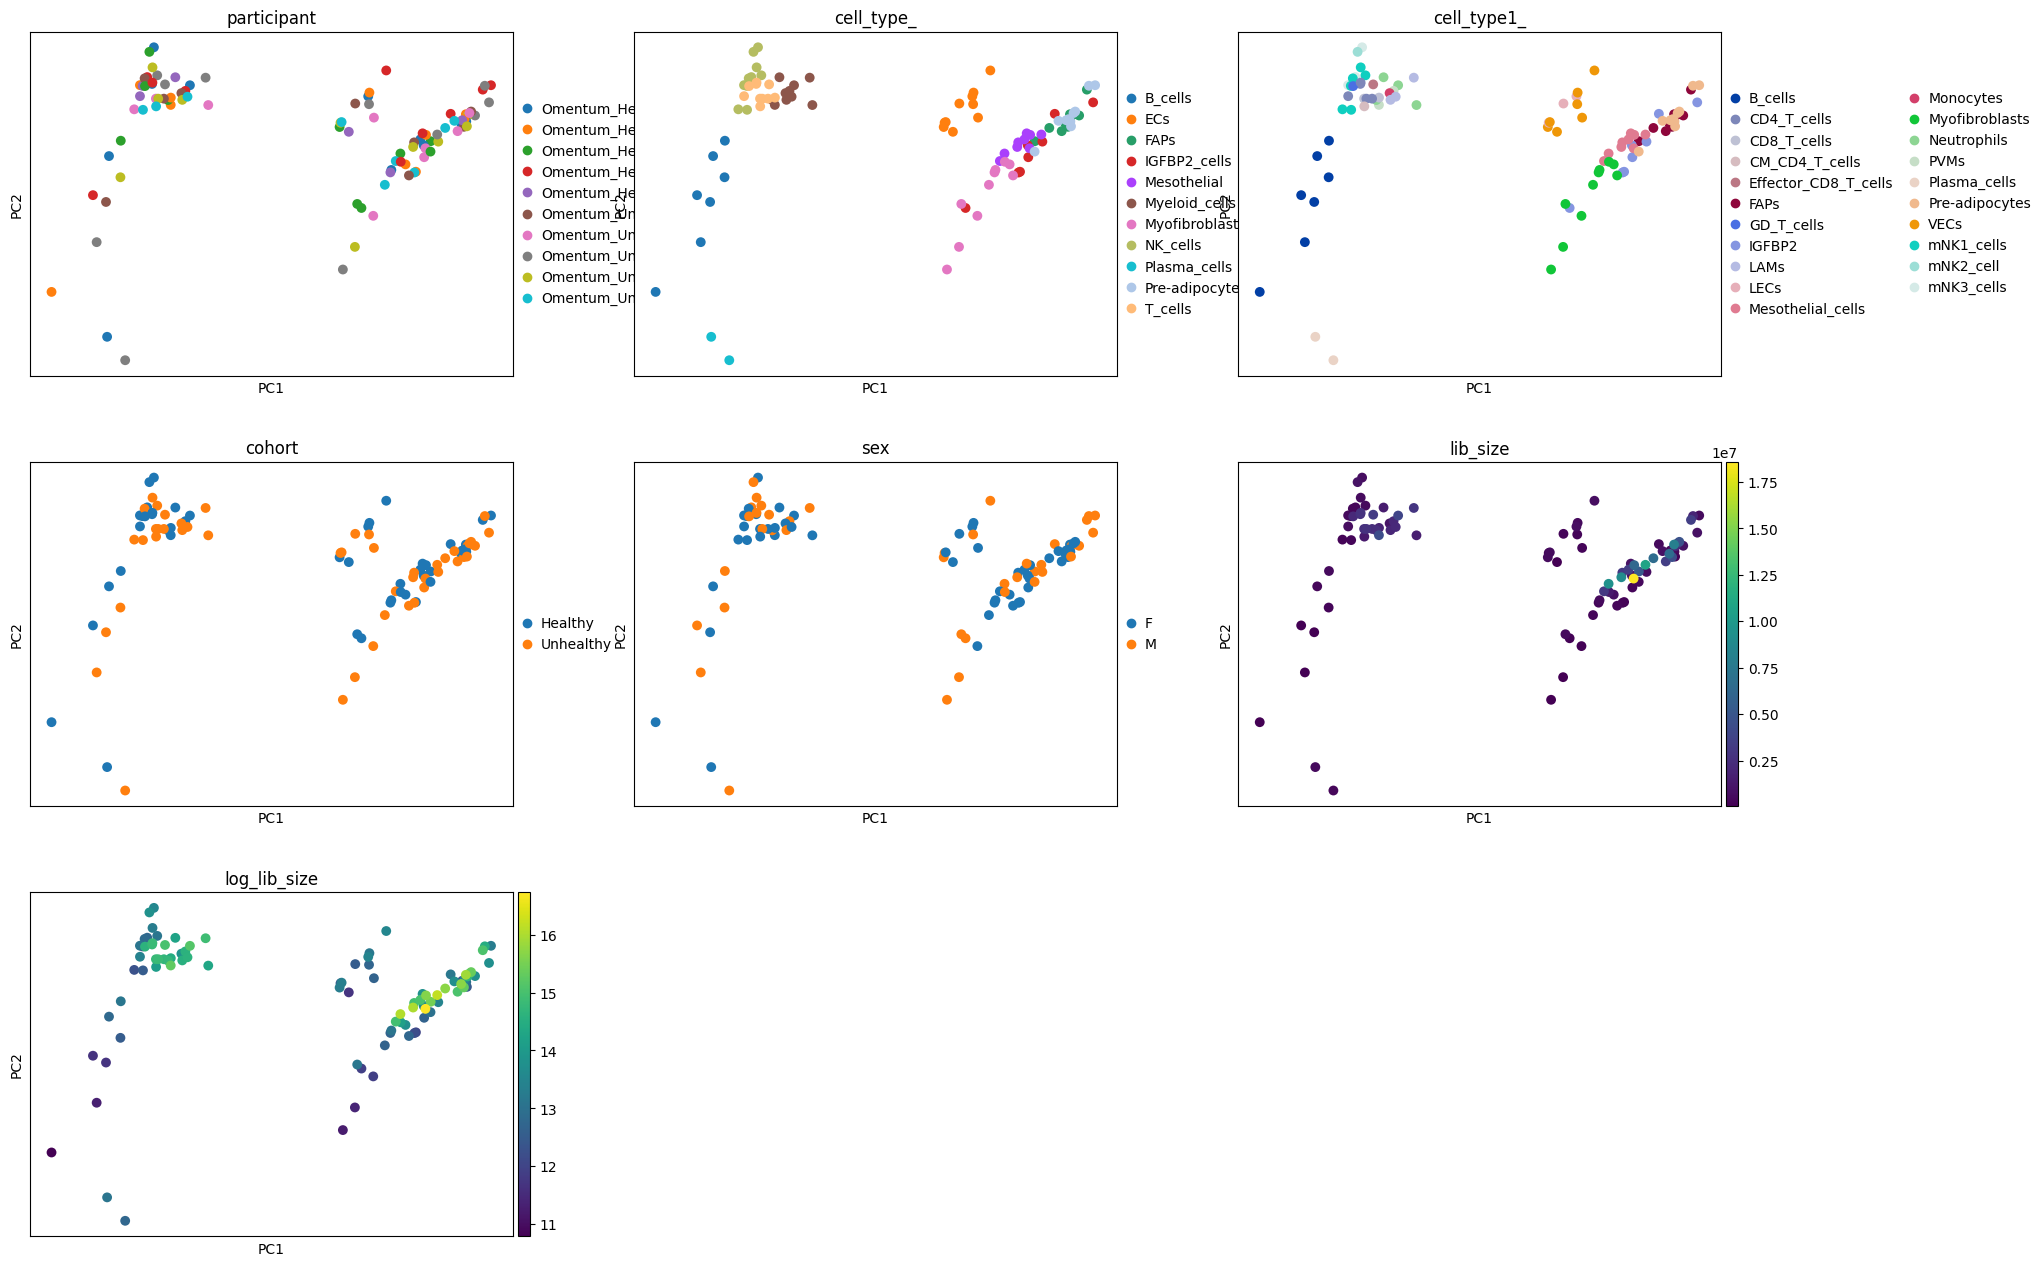

In [45]:
sc.pl.pca(adata_pb, color=adata_pb.obs, ncols=3, size=200)

### EdgeR

In [4]:
import warnings

warnings.filterwarnings("ignore")

import logging
import random

import anndata2ri
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pertpy
import rpy2.rinterface_lib.callbacks
import sc_toolbox
import scanpy as sc
import seaborn as sns
from rpy2.robjects import pandas2ri, numpy2ri

from rpy2.robjects import numpy2ri, default_converter
from rpy2.robjects.conversion import localconverter

# Combine the default converter with numpy rules
combined_converter = default_converter + numpy2ri.converter + anndata2ri.converter



sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

# pandas2ri.activate()
# anndata2ri.activate()

%load_ext rpy2.ipython

2026-05-20 22:44:25 | [INFO] cffi mode is CFFI_MODE.ANY
2026-05-20 22:44:25 | [INFO] R home found: /Library/Frameworks/R.framework/Resources
2026-05-20 22:44:26 | [INFO] R library path: 
2026-05-20 22:44:26 | [INFO] LD_LIBRARY_PATH: 
2026-05-20 22:44:26 | [WARNING] Error importing in API mode: ImportError("dlopen(/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): symbol not found in flat namespace '_R_BaseEnv'")
2026-05-20 22:44:26 | [WARNING] Trying to import in ABI mode.
2026-05-20 22:44:26 | [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2026-05-20 22:44:26 | [INFO] Environment variable "PWD" redefined by R and overriding existing variable. Current: "/Users/willtrim/Documents/projs", R: "/Users/willtrim/Documents/projs/Wills_analysis/obesity_scRNAseq"
2026-05-20 22:44:26 | [INFO] R is already initialized. No need to initialize.


In [6]:
%%R
.libPaths()

[1] "/Library/Frameworks/R.framework/Versions/4.5-x86_64/Resources/library"


In [9]:
%reload_ext rpy2.ipython

In [76]:
anndata2ri.set_ipython_converter()

In [8]:
# %%R
# BiocManager::install("MAST")


The downloaded binary packages are in
	/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T//RtmpALDDKG/downloaded_packages
Update all/some/none? [a/s/n]: 

 n


Bioconductor version 3.21 (BiocManager 1.30.27), R 4.5.1 (2025-06-13)
Installing package(s) 'MAST'
also installing the dependency ‘SingleCellExperiment’

trying URL 'https://bioconductor.org/packages/3.21/bioc/bin/macosx/big-sur-x86_64/contrib/4.5/SingleCellExperiment_1.30.1.tgz'
trying URL 'https://bioconductor.org/packages/3.21/bioc/bin/macosx/big-sur-x86_64/contrib/4.5/MAST_1.33.0.tgz'
Old packages: 'backports', 'base64enc', 'BH', 'bit64', 'blob', 'bslib',
  'circlize', 'cli', 'clue', 'cluster', 'collections', 'cpp11', 'curl',
  'data.table', 'DBI', 'dbplyr', 'devtools', 'dplyr', 'dtplyr', 'ellipsis',
  'enrichit', 'fastDummies', 'fastmatch', 'foreign', 'fs', 'futile.logger',
  'future', 'future.apply', 'gert', 'GetoptLong', 'ggplot2', 'ggrepel',
  'ggsci', 'ggstats', 'ggtangle', 'GlobalOptions', 'globals', 'glue',
  'graphlayouts', 'highr', 'htmltools', 'httpuv', 'httr', 'httr2', 'igraph',
  'isoband', 'knitr', 'languageserver', 'later', 'lattice', 'lazyeval',
  'lifecycle', 'liste

In [5]:
%%R
library(edgeR)
library(MAST)

Loading required package: limma
Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2

In [139]:
%%R
fit_model <- function(adata_, cell_type_col){
    # create an edgeR object with counts and grouping factor
    y <- DGEList(assay(adata_, "X"), group = colData(adata_)$cohort)
    # filter out genes with low counts
    print("Dimensions before subsetting:")
    print(dim(y))
    print("")
    keep <- filterByExpr(y)
    y <- y[keep, , keep.lib.sizes=FALSE]
    print("Dimensions after subsetting:")
    print(dim(y))
    print("")
    # normalize
    y <- calcNormFactors(y)
    # create a vector that is a concatenation of condition and cell type that we will later use with contrasts
    group <- paste0(colData(adata_)$cohort, ".", colData(adata_)[,cell_type_col])
    sex <- colData(adata_)$sex
    # create a design matrix: here we have multiple donors so also consider that in the design matrix
    design <- model.matrix(~ 0 + group + sex)
    # estimate dispersion
    y <- estimateDisp(y, design = design)
    # fit the model
    fit <- glmQLFit(y, design)
    return(list("fit"=fit, "design"=design, "y"=y))
}

In [52]:
adata.obs[cell_type_col].unique()

['ECs', 'Myofibroblasts', 'FAPs', 'Myeloid_cells', 'Mesothelial', ..., 'IGFBP2_cells', 'NK_cells', 'Pre-adipocytes', 'B_cells', 'Plasma_cells']
Length: 11
Categories (11, object): ['B_cells', 'ECs', 'FAPs', 'IGFBP2_cells', ..., 'NK_cells', 'Plasma_cells', 'Pre-adipocytes', 'T_cells']

In [ ]:
# genes = ["TREM2", "CD9", "CD36", "MRC1", "CD63","HLA-DRA", "HLA-DRB1", "HLA-DRB3", "HLA-DRB4", "HLA-DRB5"]
# adata.var.loc[adata.var_names.isin(genes),:]

In [332]:
adata_pb.obs.value_counts("cell_type1_")

cell_type1_
FAPs                    10
Myofibroblasts          10
Pre_adipocytes          10
Mesothelial_cells        9
IGFBP2                   8
B_cells                  7
VECs                     7
mNK1_cells               6
CD4_T_cells              5
Neutrophils              4
mNK3_cells               3
LAMs                     3
LECs                     3
Plasma_cells             2
PVMs                     2
CD8_T_cells              2
CM_CD4_T_cells           1
Effector_CD8_T_cells     1
GD_T_cells               1
Monocytes                1
mNK2_cell                1
Name: count, dtype: int64

In [337]:
with pd.option_context('display.max_rows', 300):
    print(adata.obs.value_counts(["cell_type1_", "participant"]).sort_index())

cell_type1_           participant        
B_cells               Omentum_Healthy_0        91
                      Omentum_Healthy_1        12
                      Omentum_Healthy_2       135
                      Omentum_Healthy_3        26
                      Omentum_Healthy_4         8
                      Omentum_Unhealthy_0      24
                      Omentum_Unhealthy_1       5
                      Omentum_Unhealthy_2      16
                      Omentum_Unhealthy_3      52
                      Omentum_Unhealthy_4       5
CD4_T_cells           Omentum_Healthy_0       309
                      Omentum_Healthy_1       301
                      Omentum_Healthy_2       330
                      Omentum_Healthy_3       274
                      Omentum_Healthy_4        74
                      Omentum_Unhealthy_0     181
                      Omentum_Unhealthy_1     227
                      Omentum_Unhealthy_2      76
                      Omentum_Unhealthy_3     318
        

#### One cell-type

In [68]:
adata_mono = adata_pb[adata_pb.obs[cell_type_col] == "Mesothelial"]
adata_mono

View of AnnData object with n_obs × n_vars = 9 × 26158
    obs: 'participant', 'cell_type_', 'cell_type1_', 'cohort', 'sex'

In [69]:
adata_mono.obs_names = [
    "_".join(name.split("_")[2:]) for name in adata_mono.obs_names
]

In [70]:
adata_mono.obs

,participant,cell_type_,cell_type1_,cohort,sex
Healthy_0_Mesothelial,Omentum_Healthy_0,Mesothelial,Mesothelial_cells,Healthy,F
Healthy_1_Mesothelial,Omentum_Healthy_1,Mesothelial,Mesothelial_cells,Healthy,F
Healthy_2_Mesothelial,Omentum_Healthy_2,Mesothelial,Mesothelial_cells,Healthy,M
Healthy_3_Mesothelial,Omentum_Healthy_3,Mesothelial,Mesothelial_cells,Healthy,M
Unhealthy_0_Mesothelial,Omentum_Unhealthy_0,Mesothelial,Mesothelial_cells,Unhealthy,F
Unhealthy_1_Mesothelial,Omentum_Unhealthy_1,Mesothelial,Mesothelial_cells,Unhealthy,F
Unhealthy_2_Mesothelial,Omentum_Unhealthy_2,Mesothelial,Mesothelial_cells,Unhealthy,M
Unhealthy_3_Mesothelial,Omentum_Unhealthy_3,Mesothelial,Mesothelial_cells,Unhealthy,M
Unhealthy_4_Mesothelial,Omentum_Unhealthy_4,Mesothelial,Mesothelial_cells,Unhealthy,F


In [71]:
adata_mono.X

array([[  0.,   0.,   1., ...,   0.,   1.,   0.],
       [  1.,   0.,   2., ...,   0.,   0.,   0.],
       [  1.,   0.,   2., ...,   0.,   0.,   0.],
       ...,
       [  2.,   0.,   6., ..., 187.,   0.,   0.],
       [  2.,   0.,   0., ...,   0.,   1.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.]],
      shape=(9, 26158), dtype=float32)

In [9]:
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.conversion import localconverter
# You may still need to import anndata2ri to get its converter, 
# even if you don't call activate()
import anndata2ri 

# Use a local converter instead of activating globally
with localconverter(ro.default_converter + 
                    anndata2ri.converter + 
                    pandas2ri.converter + 
                    numpy2ri.converter) as cv:
    # Now %R / %%R should work within this context
    pass 

In [10]:
from rpy2.robjects import numpy2ri, pandas2ri
from rpy2.robjects import conversion, default_converter
import anndata2ri.scipy2ri as scipy2ri

converter = (ro.default_converter
             + numpy2ri.converter
             + pandas2ri.converter
             + scipy2ri.converter
             + anndata2ri.converter)


In [59]:
from scipy import sparse

adata_mono.X = sparse.csr_matrix(adata_mono.X.astype(np.float32))

In [72]:
adata_mono

AnnData object with n_obs × n_vars = 9 × 26158
    obs: 'participant', 'cell_type_', 'cell_type1_', 'cohort', 'sex'

In [93]:
with conversion.localconverter(default_converter + numpy2ri.converter
             + anndata2ri.converter):
    # ro.globalenv['adata_mono'] = adata_mono
    # Call the function entirely from Python
    fit_model_r = ro.globalenv['fit_model']
    outs_r = fit_model_r(ro.globalenv['adata_mono'])




[1] "Dimensions before subsetting:"
[1] 26158     9
[1] ""
[1] "Dimensions after subsetting:"
[1] 12570     9
[1] ""


In [94]:
%%R
outs <-fit_model(adata_mono)

[1] "Dimensions before subsetting:"
[1] 26158     9
[1] ""
[1] "Dimensions after subsetting:"
[1] 12570     9
[1] ""


In [60]:
# Convert results back to Python (edgeR typically returns a list or data.frame)
with localconverter(ro.default_converter
             + numpy2ri.converter
             + pandas2ri.converter
             + scipy2ri.converter
             + anndata2ri.converter):
    outs = ro.conversion.rpy2py(outs_r)

In [95]:
%%R
fit <- outs$fit
y <- outs$y

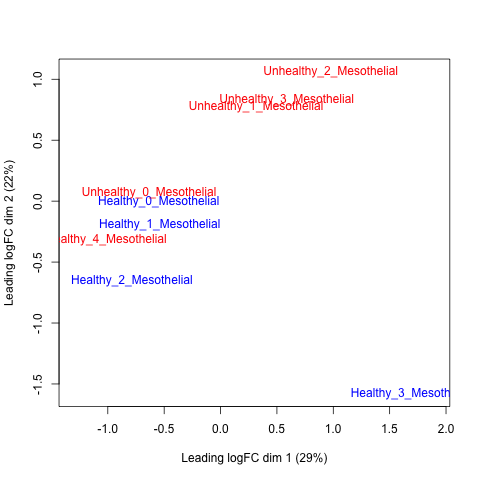

In [96]:
%%R
plotMDS(y, col=ifelse(y$samples$group == "Unhealthy", "red", "blue"))

In [79]:
%%R
y$samples

                            group lib.size norm.factors
Healthy_0_Mesothelial     Healthy  3350869    1.0380230
Healthy_1_Mesothelial     Healthy  6181428    1.0398067
Healthy_2_Mesothelial     Healthy  9314435    0.8979925
Healthy_3_Mesothelial     Healthy   951593    1.1191593
Unhealthy_0_Mesothelial Unhealthy  3111762    1.0100088
Unhealthy_1_Mesothelial Unhealthy 18516704    0.9880633
Unhealthy_2_Mesothelial Unhealthy 10735916    1.0686381
Unhealthy_3_Mesothelial Unhealthy  8881263    0.9658057
Unhealthy_4_Mesothelial Unhealthy  3032810    0.8950461


In [97]:
%%R
y$samples$sex <- colData(adata_mono)$sex

In [91]:
adata_mono.X

array([[  0.,   0.,   1., ...,   0.,   1.,   0.],
       [  1.,   0.,   2., ...,   0.,   0.,   0.],
       [  1.,   0.,   2., ...,   0.,   0.,   0.],
       ...,
       [  2.,   0.,   6., ..., 187.,   0.,   0.],
       [  2.,   0.,   0., ...,   0.,   1.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.]],
      shape=(9, 26158), dtype=float32)

In [80]:
%%R
outs

$fit
An object of class "DGEGLM"
$coefficients
          groupHealthy.Mesothelial groupUnhealthy.Mesothelial        sexM
LINC01128                -11.84205                  -11.96740 -0.18362250
SAMD11                   -11.50520                  -11.72835 -0.23911174
NOC2L                    -10.07979                  -10.61084 -0.08429683
KLHL17                   -13.61007                  -13.16710 -0.01394766
HES4                     -10.47509                  -11.79780 -0.28060944
12565 more rows ...

$fitted.values
          Healthy_0_Mesothelial Healthy_1_Mesothelial Healthy_2_Mesothelial
LINC01128             24.966902             46.136183             49.943637
SAMD11                34.989011             64.655978             66.222218
NOC2L                145.746242            269.323581            322.116824
KLHL17                 4.208562              7.776976              9.983175
HES4                  98.174797            181.416601            178.178277
          Healthy

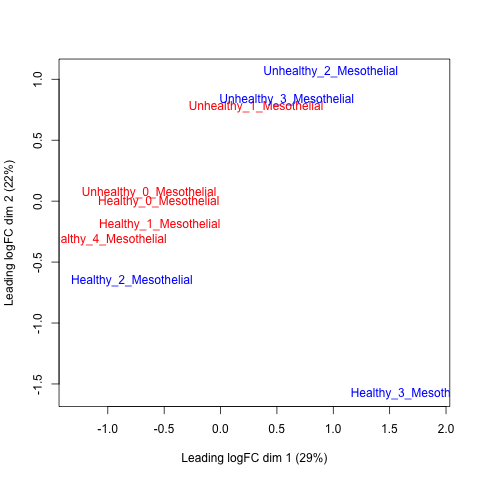

In [98]:
%%R
plotMDS(y, col=ifelse(y$samples$sex == "F", "red", "blue"))

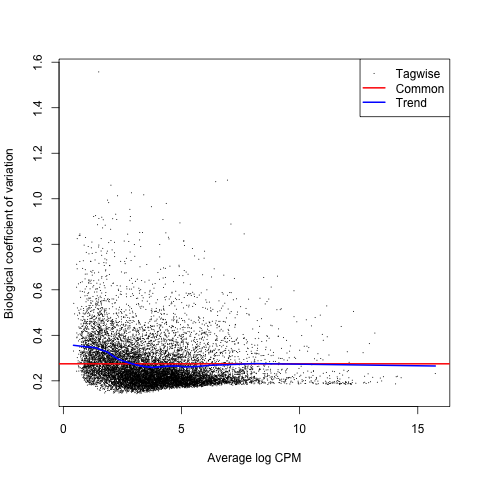

In [77]:
%%R
plotBCV(y)

In addition: Warning message:
In plot.xy(xy.coords(x, y), type = type, ...) :
  "panel.first" is not a graphical parameter


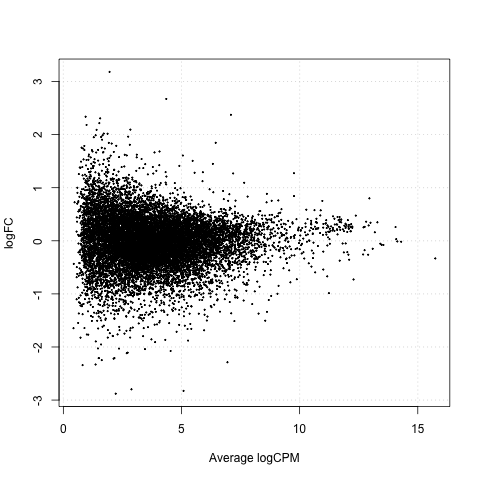

In [99]:
%%R
plotSmear(qlf, de.tags = rownames(tt)[which(tt$FDR<0.01)])

In [44]:
%%R
adata_mono

class: SingleCellExperiment 
dim: 26158 10 
metadata(0):
assays(1): X
rownames(26158): AL627309.1 AL627309.3 ... AC007325.4 AC007325.2
rowData names(0):
colnames(10): Healthy_0_Myofibroblasts Healthy_1_Myofibroblasts ...
  Unhealthy_3_Myofibroblasts Unhealthy_4_Myofibroblasts
colData names(5): participant cell_type_ cell_type1_ cohort sex
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):


In [85]:
%%R
colnames(y$design)

[1] "groupHealthy.Mesothelial"   "groupUnhealthy.Mesothelial"
[3] "sexM"                      


In [86]:
%%R -o tt
myContrast <- makeContrasts('groupUnhealthy.Mesothelial-groupHealthy.Mesothelial', levels = y$design)
qlf <- glmQLFTest(fit, contrast=myContrast)
# get all of the DE genes and calculate Benjamini-Hochberg adjusted FDR
tt <- topTags(qlf, n = Inf)
tt <- tt$table

In [90]:
tt.sort_values("FDR")

,logFC,logCPM,F,PValue,FDR
IGLC2,1.960951,2.742144,6.307683e+01,0.000008,0.092974
GZMB,-2.219900,2.127392,5.386480e+01,0.000017,0.092974
LYZ,-1.634021,2.938181,5.043359e+01,0.000022,0.092974
MPRIP-AS1,-2.030683,2.355321,4.023602e+01,0.000061,0.193041
ZBED8,2.336937,0.943231,2.101979e+01,0.000514,0.267288
...,...,...,...,...,...
ENY2,0.000115,7.624528,6.659805e-07,0.999364,0.999682
HSDL2,-0.000095,4.746210,2.674839e-07,0.999597,0.999835
TOM1L2,-0.000096,3.731661,7.918441e-08,0.999781,0.999871
AHCYL2,0.000053,2.029195,7.159579e-08,0.999791,0.999871


In [242]:
tt.loc["TXNIP",:]

logFC     1.273402
logCPM    9.760425
F         4.386767
PValue    0.060640
FDR       0.329631
Name: TXNIP, dtype: float64

In [247]:
adata_atm

AnnData object with n_obs × n_vars = 4972 × 26144
    obs: 'status', 'assignment', 'singlet_posterior', 'doublet_posterior', 'log_prob_singleton', 'log_prob_doublet', 'cluster0', 'cluster1', 'cluster2', 'cluster3', 'cluster4', 'sample_name', 'disease', 'tissue', 'cohort', 'participant', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden', 'leiden_res_0.02', 'leiden_res_0.20', 'leiden_res_0.30', 'leiden_res_0.40', 'leiden_res_0.50', 'leiden_res_0.60', 'leiden_res_1.00', 'cell_type', 'cd45', 'cell_type1', 'scrublet_score', 'scrublet_call', 'lib_name', 'sex', 'cell_type_', 'cell_type1_'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_co

cell_type2_
Mesothelial_cells    4972
MMT_cells              37
Name: count, dtype: int64


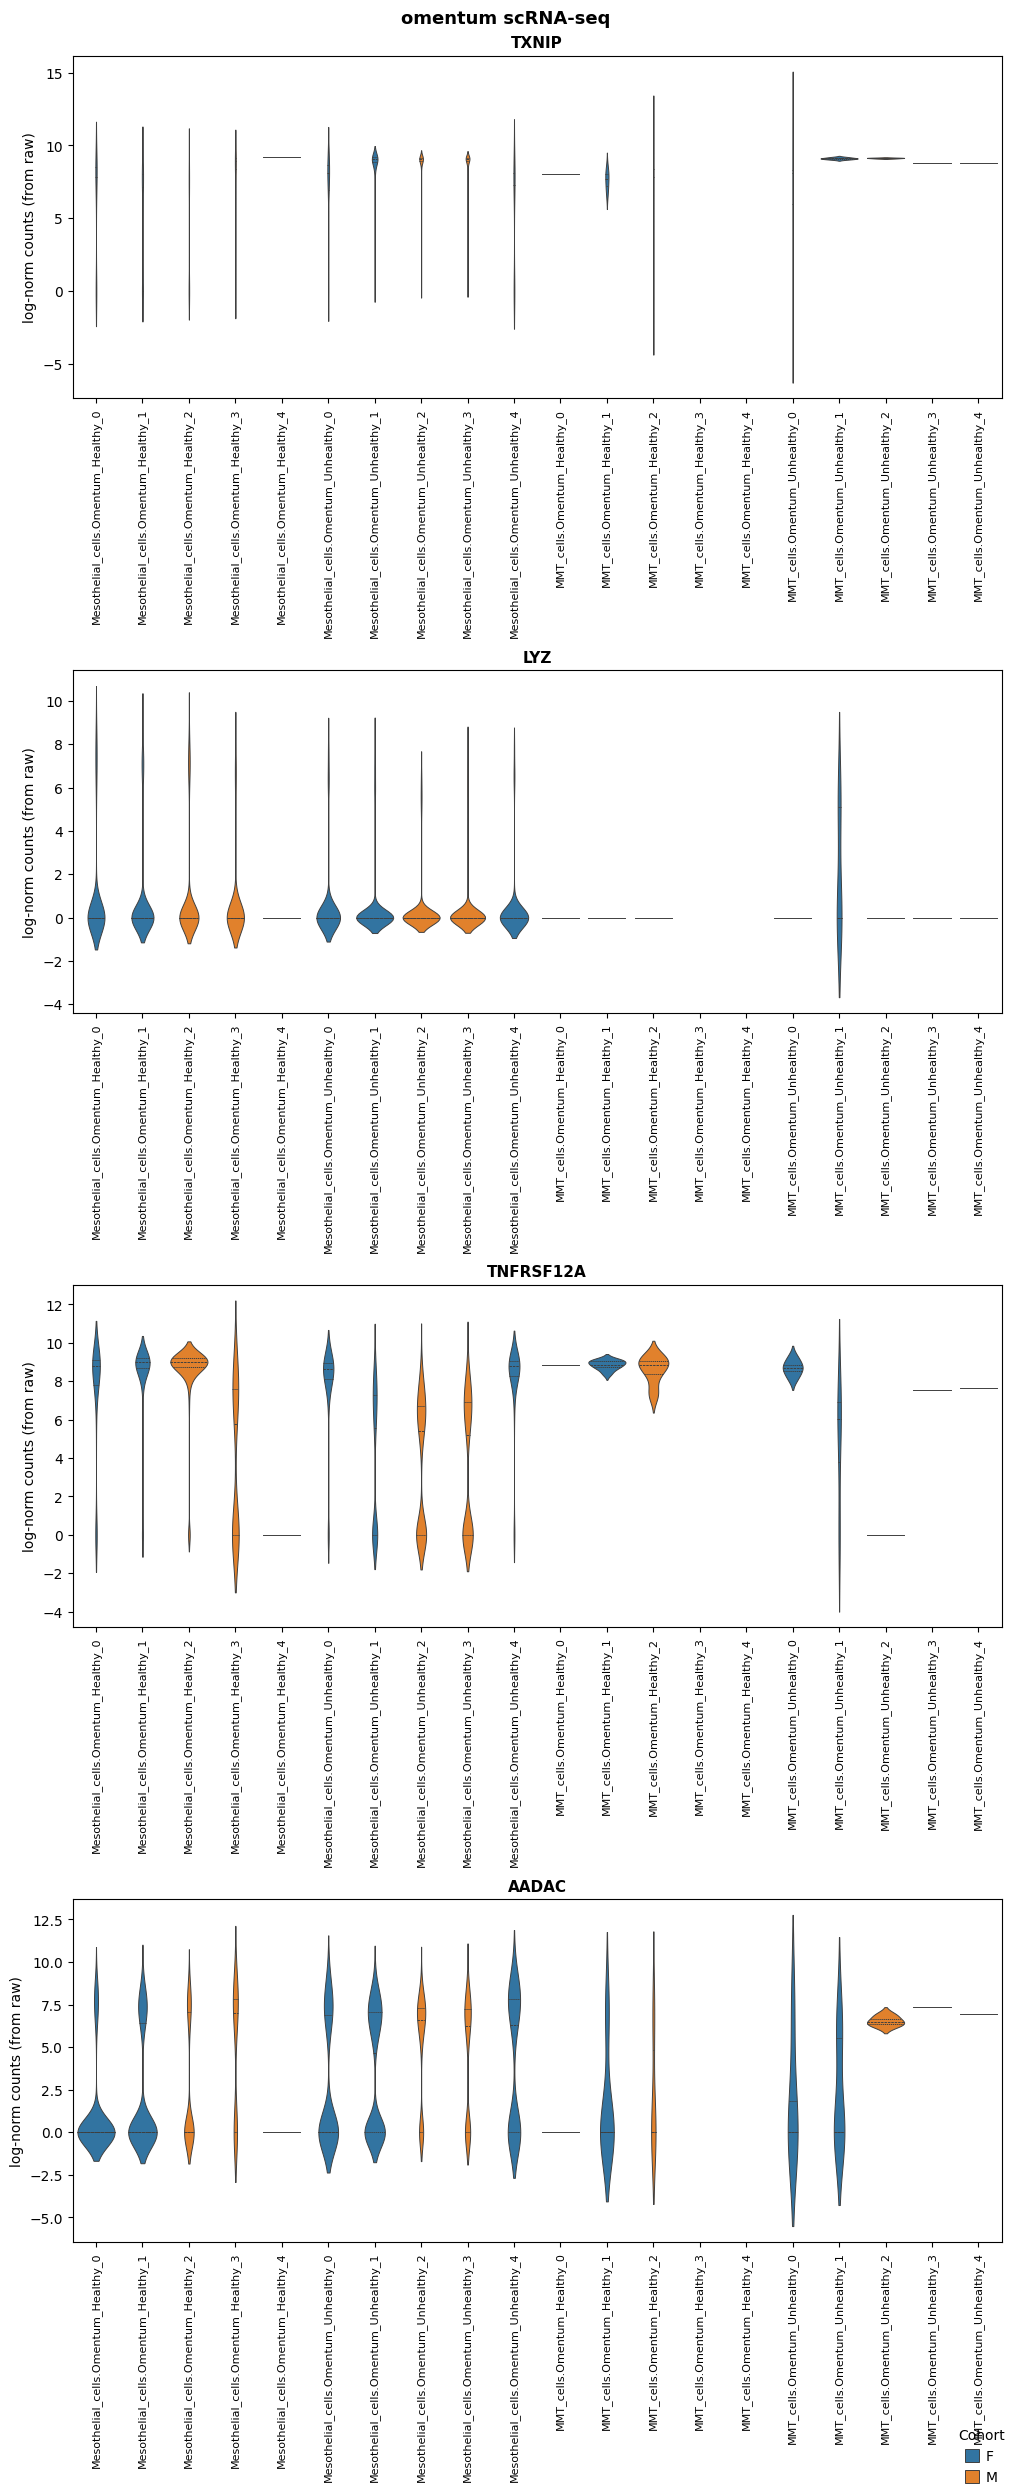

In [480]:
import numpy as np
import scipy.sparse as sp

ATM_TYPES = ["Mesothelial_cells", "MMT_cells"]
MARKERS = ["TXNIP", "LYZ", "TNFRSF12A", "AADAC"]

cell_type_col = "cell_type2_"
# Subset to ATM populations
adata_atm = adata[adata.obs[cell_type_col].isin(ATM_TYPES)].copy()
print(adata_atm.obs[cell_type_col].value_counts())

# Filter to genes present in the dataset
markers_present = [g for g in MARKERS if g in adata_atm.var_names]
missing = set(MARKERS) - set(markers_present)
if missing:
    print(f"Genes not found in adata: {missing}")

# Extract expression — adata.X is assumed to be log-normalised.
# If adata has a "counts" layer, normalise from that instead.
if "counts" in adata_atm.layers:
    X_raw = adata_atm[:, markers_present].layers["counts"]
    if sp.issparse(X_raw):
        X_raw = X_raw.toarray().astype(float)
    row_sums = X_raw.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    X_plot = np.log1p(X_raw / row_sums * 1e4)
    ylabel = "log-norm counts (from raw)"
else:
    X_plot = adata_atm[:, markers_present].X
    if sp.issparse(X_plot):
        X_plot = X_plot.toarray()
    ylabel = "log-norm counts"

# Build tidy DataFrame
expr_df = pd.DataFrame(X_plot, columns=markers_present)
expr_df["cell_type"] = adata_atm.obs[cell_type_col].values
expr_df["cohort"]    = adata_atm.obs["cohort"].values
expr_df["participant"]    = adata_atm.obs["participant"].values
expr_df["sex"]    = adata_atm.obs["sex"].values
long_df = expr_df.melt(id_vars=["cell_type", "cohort", "participant", "sex"], var_name="gene", value_name="expression")

# Plot — one subplot per gene, split violins by cohort
NCOLS = 1
NROWS = int(np.ceil(len(markers_present) / NCOLS))
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(10, NROWS * 6.2), constrained_layout=True)
axes = axes.flatten()

palette  = {"Healthy": "#4878CF", "Unhealthy": "#D65F5F"}
pb_order = [f"{ct}.{participant}" for ct in ATM_TYPES if ct in expr_df["cell_type"].values for participant in long_df["participant"].cat.categories]
long_df["pb_sample"] = long_df["cell_type"].astype(str) + "." + long_df["participant"].astype(str)

for i, gene in enumerate(markers_present):
    ax = axes[i]
    sns.violinplot(
        data=long_df[long_df["gene"] == gene],
        x="pb_sample", y="expression",
        hue="sex", #, split=True
        order=pb_order,
        # palette=palette,
        inner="quart",
        linewidth=0.7,
        ax=ax,
        common_norm=False,
        density_norm="area"
    )
    ax.set_title(gene, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel if i % NCOLS == 0 else "")
    ax.tick_params(axis="x", labelsize=8, rotation=90)
    if i > 0 and ax.get_legend() is not None:
        ax.get_legend().remove()

# hide unused axes
for j in range(len(markers_present), len(axes)):
    axes[j].set_visible(False)

# single shared legend from first axis
handles, labels = axes[0].get_legend_handles_labels()
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()
fig.legend(handles, labels, title="Cohort", loc="lower right", fontsize=10, title_fontsize=10)

fig.suptitle("omentum scRNA-seq", fontsize=13, fontweight="bold")
os.makedirs("results", exist_ok=True)
# plt.savefig("results/ATM_markers_violin.pdf", bbox_inches="tight")
plt.show()

cell_type2_
FAPs    6787
Name: count, dtype: int64


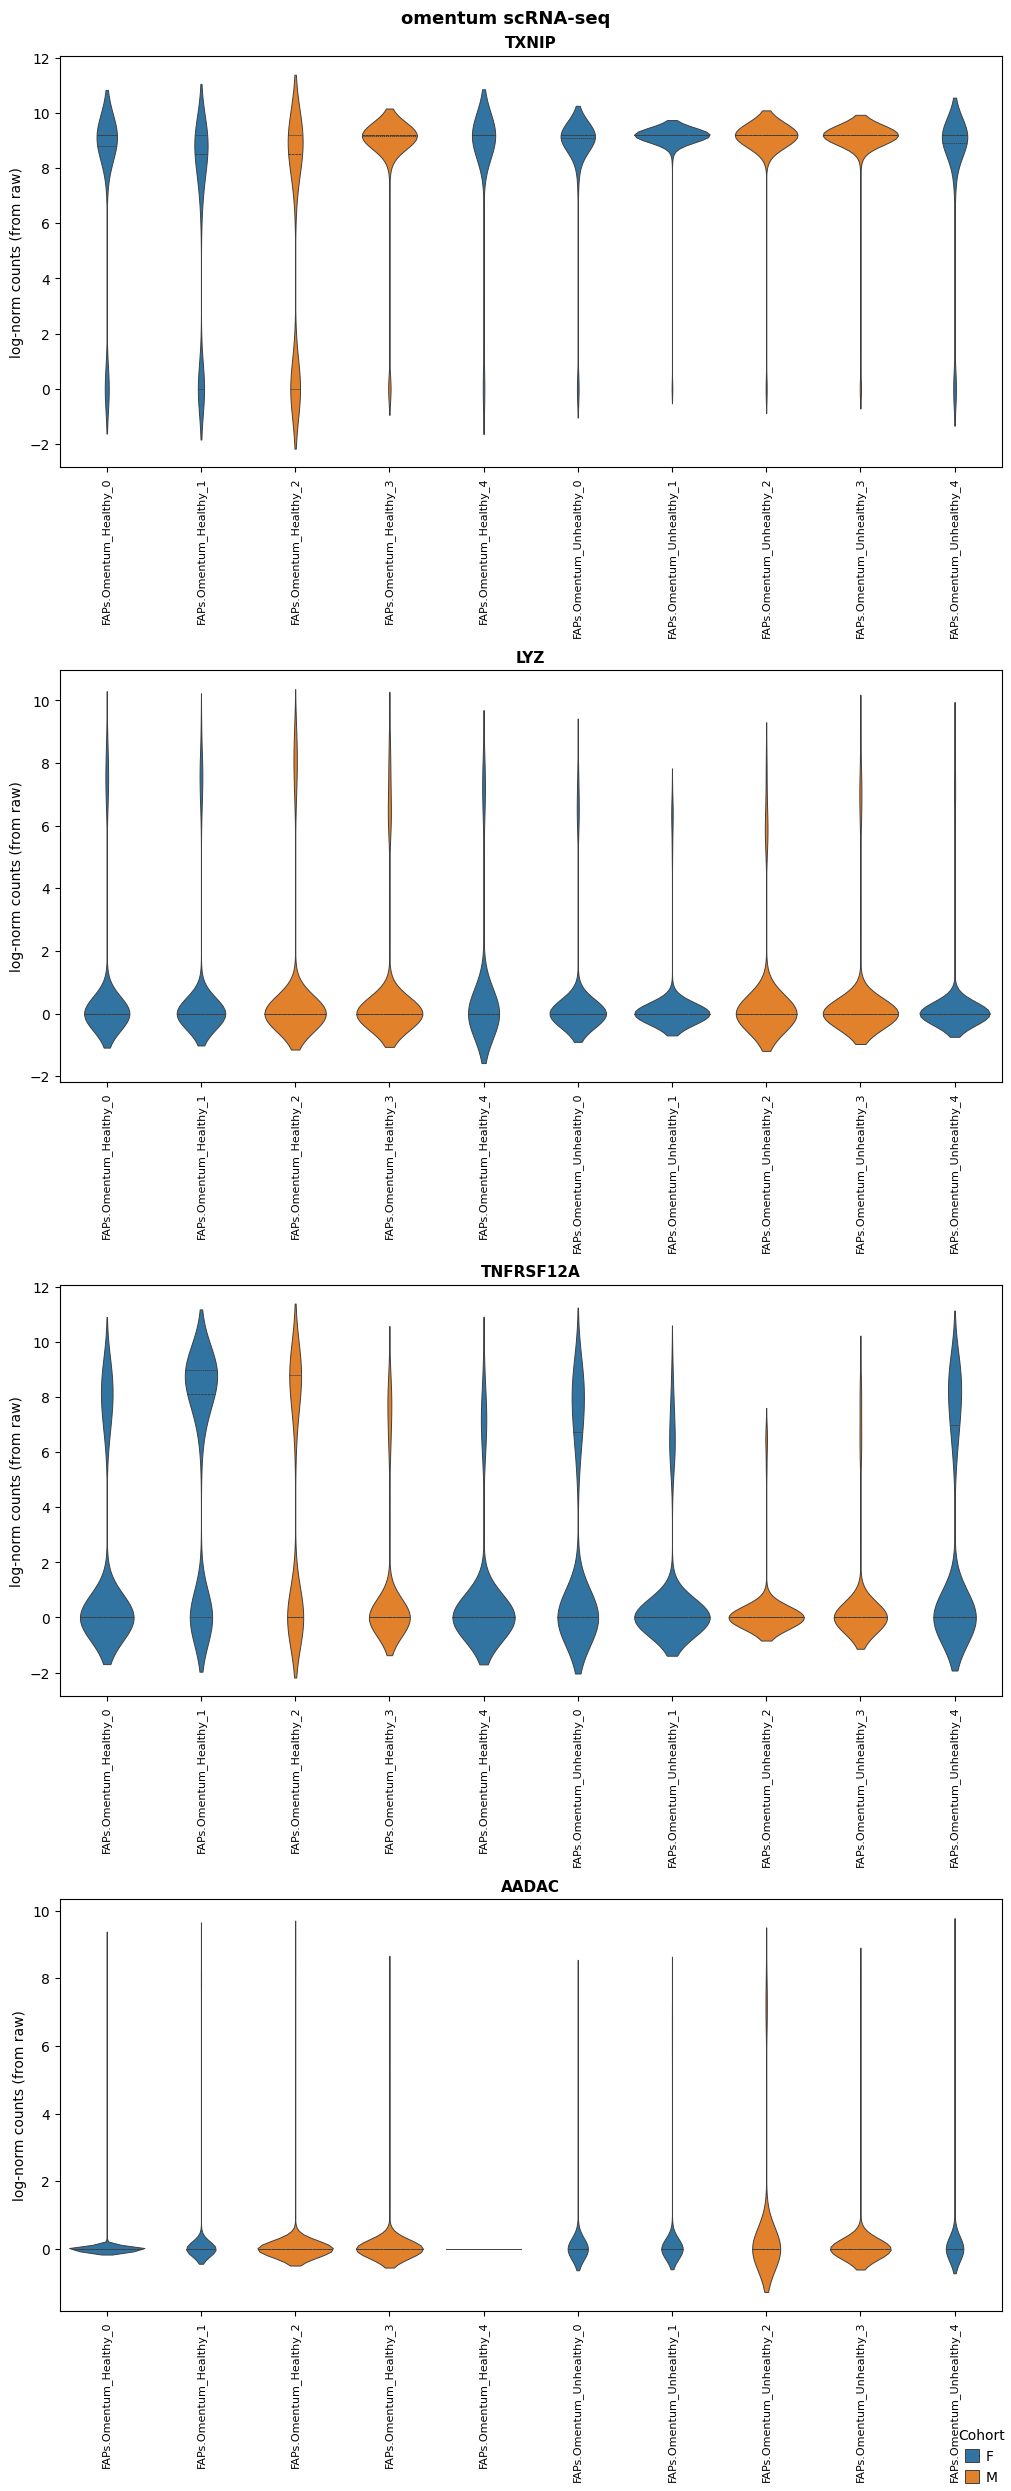

In [481]:
import numpy as np
import scipy.sparse as sp

ATM_TYPES = ["FAPs"]
MARKERS = ["TXNIP", "LYZ", "TNFRSF12A", "AADAC"]

cell_type_col = "cell_type2_"
# Subset to ATM populations
adata_atm = adata[adata.obs[cell_type_col].isin(ATM_TYPES)].copy()
print(adata_atm.obs[cell_type_col].value_counts())

# Filter to genes present in the dataset
markers_present = [g for g in MARKERS if g in adata_atm.var_names]
missing = set(MARKERS) - set(markers_present)
if missing:
    print(f"Genes not found in adata: {missing}")

# Extract expression — adata.X is assumed to be log-normalised.
# If adata has a "counts" layer, normalise from that instead.
if "counts" in adata_atm.layers:
    X_raw = adata_atm[:, markers_present].layers["counts"]
    if sp.issparse(X_raw):
        X_raw = X_raw.toarray().astype(float)
    row_sums = X_raw.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    X_plot = np.log1p(X_raw / row_sums * 1e4)
    ylabel = "log-norm counts (from raw)"
else:
    X_plot = adata_atm[:, markers_present].X
    if sp.issparse(X_plot):
        X_plot = X_plot.toarray()
    ylabel = "log-norm counts"

# Build tidy DataFrame
expr_df = pd.DataFrame(X_plot, columns=markers_present)
expr_df["cell_type"] = adata_atm.obs[cell_type_col].values
expr_df["cohort"]    = adata_atm.obs["cohort"].values
expr_df["participant"]    = adata_atm.obs["participant"].values
expr_df["sex"]    = adata_atm.obs["sex"].values
long_df = expr_df.melt(id_vars=["cell_type", "cohort", "participant", "sex"], var_name="gene", value_name="expression")

# Plot — one subplot per gene, split violins by cohort
NCOLS = 1
NROWS = int(np.ceil(len(markers_present) / NCOLS))
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(10, NROWS * 6.2), constrained_layout=True)
axes = axes.flatten()

palette  = {"Healthy": "#4878CF", "Unhealthy": "#D65F5F"}
pb_order = [f"{ct}.{participant}" for ct in ATM_TYPES if ct in expr_df["cell_type"].values for participant in long_df["participant"].cat.categories]
long_df["pb_sample"] = long_df["cell_type"].astype(str) + "." + long_df["participant"].astype(str)

for i, gene in enumerate(markers_present):
    ax = axes[i]
    sns.violinplot(
        data=long_df[long_df["gene"] == gene],
        x="pb_sample", y="expression",
        hue="sex", #, split=True
        order=pb_order,
        # palette=palette,
        inner="quart",
        linewidth=0.7,
        ax=ax,
        common_norm=False,
        density_norm="area"
    )
    ax.set_title(gene, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel if i % NCOLS == 0 else "")
    ax.tick_params(axis="x", labelsize=8, rotation=90)
    if i > 0 and ax.get_legend() is not None:
        ax.get_legend().remove()

# hide unused axes
for j in range(len(markers_present), len(axes)):
    axes[j].set_visible(False)

# single shared legend from first axis
handles, labels = axes[0].get_legend_handles_labels()
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()
fig.legend(handles, labels, title="Cohort", loc="lower right", fontsize=10, title_fontsize=10)

fig.suptitle("omentum scRNA-seq", fontsize=13, fontweight="bold")
os.makedirs("results", exist_ok=True)
# plt.savefig("results/ATM_markers_violin.pdf", bbox_inches="tight")
plt.show()

In [374]:
long_df

,cell_type,cohort,participant,sex,gene,expression
0,Mesothelial_cells,Healthy,Omentum_Healthy_1,F,TXNIP,9.210440
1,Mesothelial_cells,Healthy,Omentum_Healthy_1,F,TXNIP,0.000000
2,Mesothelial_cells,Healthy,Omentum_Healthy_1,F,TXNIP,0.000000
3,Mesothelial_cells,Healthy,Omentum_Healthy_1,F,TXNIP,9.210440
4,Mesothelial_cells,Healthy,Omentum_Healthy_0,F,TXNIP,8.517393
...,...,...,...,...,...,...
10013,Mesothelial_cells,Unhealthy,Omentum_Unhealthy_1,F,LYZ,0.000000
10014,Mesothelial_cells,Unhealthy,Omentum_Unhealthy_1,F,LYZ,0.000000
10015,Mesothelial_cells,Unhealthy,Omentum_Unhealthy_0,F,LYZ,8.112028
10016,Mesothelial_cells,Unhealthy,Omentum_Unhealthy_3,M,LYZ,0.000000


In [281]:
adata.obs.value_counts("participant")

participant
Omentum_Healthy_1      3769
Omentum_Healthy_2      3722
Omentum_Healthy_0      3563
Omentum_Healthy_3      2790
Omentum_Unhealthy_1    2562
Omentum_Unhealthy_2    2342
Omentum_Unhealthy_3    2240
Omentum_Unhealthy_0    2124
Omentum_Unhealthy_4    1988
Omentum_Healthy_4       730
Name: count, dtype: int64

In [288]:
adata_4 = adata[adata.obs.participant == "Omentum_Healthy_4"]
adata_4.obs.value_counts(["cd45", "cell_type"]).sort_index()

cd45  cell_type     
neg   ECs                33
      FAPs              145
      Mesothelial         1
      Myofibroblasts     60
      Pre-adipocytes     37
pos   B cells             8
      Myeloid cells     218
      NK cells           60
      T cells           168
Name: count, dtype: int64

In [289]:
adata_1 = adata[adata.obs.participant == "Omentum_Unhealthy_1"]
adata_1.obs.value_counts(["cd45", "cell_type"]).sort_index()

cd45  cell_type     
neg   ECs                 48
      FAPs               351
      IGFBP2+ cells       31
      Mesothelial       1128
      Myofibroblasts      18
      Pre-adipocytes     179
pos   B cells              5
      Myeloid cells      142
      NK cells            47
      Plasma cells         4
      T cells            609
Name: count, dtype: int64

In [267]:
adata_mono.X.sum(axis=1)

matrix([[11416.],
        [ 9869.],
        [ 7448.],
        ...,
        [ 7302.],
        [13584.],
        [ 6634.]], shape=(5009, 1), dtype=float32)

In [268]:
adata_mono_ = adata_mono.copy()

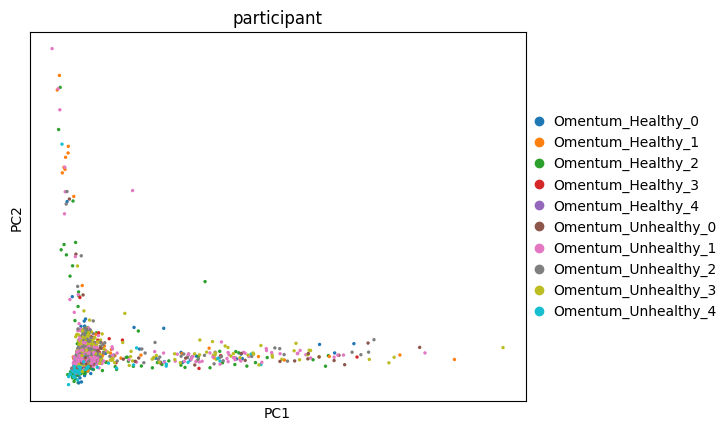

In [269]:
sc.experimental.pp.recipe_pearson_residuals(adata_mono_, batch_key="participant", theta=1)

sc.pl.pca(adata_mono_, color=["participant",])
plt.show()

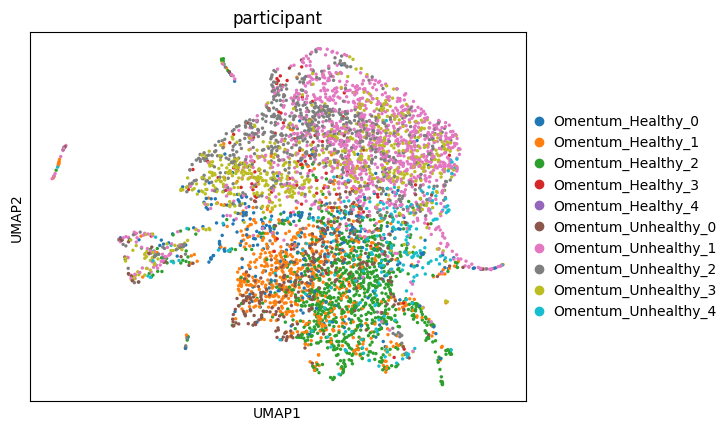

In [273]:
sc.pp.neighbors(adata_mono_, n_pcs=10, n_neighbors=5)
sc.tl.umap(adata_mono_, )
sc.pl.umap(adata_mono_, color=["participant",])

In [275]:
sc.pp.normalize_total(adata_mono_)
# Logarithmize the data
sc.pp.log1p(adata_mono_)

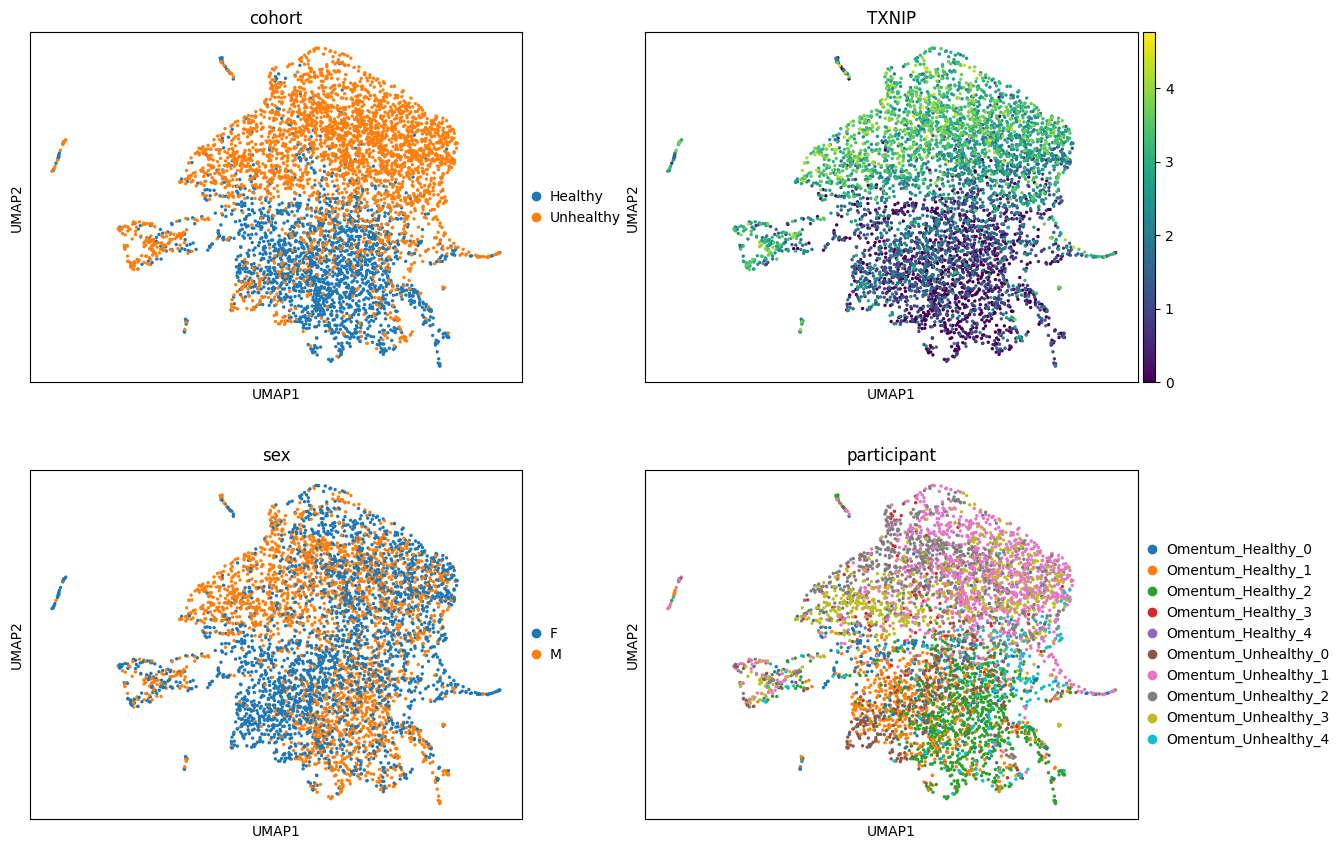

In [291]:
sc.pl.umap(adata_mono_, color=["cohort", "TXNIP", "sex", "participant"], ncols=2)

#### all cell types together

In [133]:
print(", ".join(adata_pb.obs[cell_type_col].unique()))

B_cells, ECs, FAPs, IGFBP2_cells, Mesothelial, Myeloid_cells, Myofibroblasts, NK_cells, Plasma_cells, Pre_adipocytes, T_cells


In [134]:
with conversion.localconverter(default_converter + numpy2ri.converter
             + anndata2ri.converter):
    ro.globalenv['adata'] = adata_pb

In [140]:
%%R
outs <-fit_model(adata)
fit <- outs$fit
y <- outs$y

[1] "Dimensions before subsetting:"
[1] 26158    96
[1] ""
[1] "Dimensions after subsetting:"
[1] 6558   96
[1] ""


In [141]:
%%R
colnames(y$design)

 [1] "groupHealthy.B_cells"          "groupHealthy.ECs"             
 [3] "groupHealthy.FAPs"             "groupHealthy.IGFBP2_cells"    
 [5] "groupHealthy.Mesothelial"      "groupHealthy.Myeloid_cells"   
 [7] "groupHealthy.Myofibroblasts"   "groupHealthy.NK_cells"        
 [9] "groupHealthy.Plasma_cells"     "groupHealthy.Pre_adipocytes"  
[11] "groupHealthy.T_cells"          "groupUnhealthy.B_cells"       
[13] "groupUnhealthy.ECs"            "groupUnhealthy.FAPs"          
[15] "groupUnhealthy.IGFBP2_cells"   "groupUnhealthy.Mesothelial"   
[17] "groupUnhealthy.Myeloid_cells"  "groupUnhealthy.Myofibroblasts"
[19] "groupUnhealthy.NK_cells"       "groupUnhealthy.Plasma_cells"  
[21] "groupUnhealthy.Pre_adipocytes" "groupUnhealthy.T_cells"       
[23] "sexM"                         


In [143]:
%%R -o de_per_cell_type

de_per_cell_type <- list()

for (cell_type in unique(colData(adata)$cell_type_)) {
    print(cell_type)
    # create contrast for this cell type
    myContrast <- makeContrasts(paste0("groupUnhealthy.", cell_type, "-groupHealthy.", cell_type), levels = y$design)
    # perform QLF test
    qlf <- glmQLFTest(fit, contrast=myContrast)
    # get all of the DE genes and calculate Benjamini-Hochberg adjusted FDR
    tt <- topTags(qlf, n = Inf)
    # save in the list with the results for all the cell types
    de_per_cell_type[[cell_type]] <- tt$table
}

[1] "B_cells"
[1] "ECs"
[1] "FAPs"
[1] "IGFBP2_cells"
[1] "Mesothelial"
[1] "Myeloid_cells"
[1] "Myofibroblasts"
[1] "NK_cells"
[1] "Plasma_cells"
[1] "Pre_adipocytes"
[1] "T_cells"


In [153]:
de_per_cell_type = dict(zip(de_per_cell_type.names(), de_per_cell_type))

In [151]:
list(de_per_cell_type.names())

[np.str_('B_cells'),
 np.str_('ECs'),
 np.str_('FAPs'),
 np.str_('IGFBP2_cells'),
 np.str_('Mesothelial'),
 np.str_('Myeloid_cells'),
 np.str_('Myofibroblasts'),
 np.str_('NK_cells'),
 np.str_('Plasma_cells'),
 np.str_('Pre_adipocytes'),
 np.str_('T_cells')]

In [154]:
# get cell types that we ran the analysis for
cell_types = de_per_cell_type.keys()
# add the table to .uns for each cell type
for cell_type in cell_types:
    df = de_per_cell_type[cell_type]
    df["gene_symbol"] = df.index
    df["cell_type"] = cell_type
    sc_toolbox.tools.de_res_to_anndata(
        adata,
        df,
        groupby="cell_type",
        score_col="logCPM",
        pval_col="PValue",
        pval_adj_col="FDR",
        lfc_col="logFC",
        key_added="edgeR_" + cell_type,
    )
    # df.to_csv(f"de_edgeR_{cell_type}.csv")

In [390]:
adata_pb.obs

,participant,cell_type_,cell_type1_,cohort,sex
donor_Omentum_Healthy_0_B_cells,Omentum_Healthy_0,B_cells,B_cells,Healthy,F
donor_Omentum_Healthy_1_B_cells,Omentum_Healthy_1,B_cells,B_cells,Healthy,F
donor_Omentum_Healthy_2_B_cells,Omentum_Healthy_2,B_cells,B_cells,Healthy,M
donor_Omentum_Healthy_3_B_cells,Omentum_Healthy_3,B_cells,B_cells,Healthy,M
donor_Omentum_Unhealthy_0_B_cells,Omentum_Unhealthy_0,B_cells,B_cells,Unhealthy,F
...,...,...,...,...,...
donor_Omentum_Unhealthy_0_T_cells,Omentum_Unhealthy_0,T_cells,CD4_T_cells,Unhealthy,F
donor_Omentum_Unhealthy_1_T_cells,Omentum_Unhealthy_1,T_cells,CD8_T_cells,Unhealthy,F
donor_Omentum_Unhealthy_2_T_cells,Omentum_Unhealthy_2,T_cells,Effector_CD8_T_cells,Unhealthy,M
donor_Omentum_Unhealthy_3_T_cells,Omentum_Unhealthy_3,T_cells,CD4_T_cells,Unhealthy,M


for cell_type in cell_types:
    print(cell_type)
    print(sc.get.rank_genes_groups_df(adata, group=cell_type, key=f"edgeR_{cell_type}").sort_values("pvals_adj").head(5))
    print("---------------------------------------------------")

#### all cell types one-by-one

In [382]:
%%R
fit_model <- function(adata_, cell_type_col){
    # create an edgeR object with counts and grouping factor
    y <- DGEList(assay(adata_, "X"), group = colData(adata_)$cohort)
    # filter out genes with low counts
    print("Dimensions before subsetting:")
    print(dim(y))
    print("")
    keep <- filterByExpr(y)
    y <- y[keep, , keep.lib.sizes=FALSE]
    print("Dimensions after subsetting:")
    print(dim(y))
    print("")
    # normalize
    y <- calcNormFactors(y)
    # create a vector that is a concatenation of condition and cell type that we will later use with contrasts
    group <- paste0(colData(adata_)$cohort, ".", colData(adata_)[,cell_type_col])
    sex <- colData(adata_)$sex
    # create a design matrix: here we have multiple donors so also consider that in the design matrix
    design <- model.matrix(~ 0 + group + sex)
    # estimate dispersion
    y <- estimateDisp(y, design = design)
    # fit the model
    fit <- glmQLFit(y, design)
    return(list("fit"=fit, "design"=design, "y"=y))
}

In [399]:
cell_type_col = "cell_type2_"

results_per_ct = {}
res_list = []
skipped = []


adata_pb = sc.read_h5ad(
    "/Users/willtrim/Documents/projs/Wills_analysis/obesity_scRNAseq/inputs/anndatas/omentum_reannotated_finely_pb_cell_type2_.h5ad"
)
adata_pb.obs[cell_type_col] = adata_pb.obs[cell_type_col].astype("str").str.replace("-", "_")
adata_pb.obs[cell_type_col] = adata_pb.obs[cell_type_col].astype("str").str.replace("?", "_")

for ct in sorted(adata_pb.obs[cell_type_col].unique()):
    pdata_ct = adata_pb[adata_pb.obs[cell_type_col] == ct].copy()

    # sc.pp.filter_genes(pdata_ct, min_cells=1)
    # sc.pp.filter_genes(pdata_ct, min_counts=10)

    # Need both cohort levels and enough samples for sex+cohort design
    cohorts_present = pdata_ct.obs["cohort"].nunique()
    sexes_present = pdata_ct.obs["sex"].nunique()
    n = pdata_ct.n_obs

    if cohorts_present < 2:
        skipped.append((ct, f"n={n}, only one cohort"))
        continue
    if n < 6:
        skipped.append((ct, f"n={n}, too few samples for sex+cohort design"))
        continue
    if sexes_present < 2:
        skipped.append((ct, f"sexes_present={sexes_present}, too few samples for sex+cohort design"))
        continue
    
    design = "~sex+cohort" #if sexes_present > 1 else "~cohort"

    with conversion.localconverter(default_converter + numpy2ri.converter
             + anndata2ri.converter):
        ro.globalenv['pdata_ct'] = pdata_ct
        # Call the function entirely from Python
        # fit_model_r = ro.globalenv['fit_model']
        # outs_r = fit_model_r(ro.globalenv['adata_mono'], cell_type_col)
        %R -i cell_type_col outs <- fit_model(pdata_ct, cell_type_col)
        %R fit <- outs$fit
        %R y <- outs$y
        contrast = f"groupUnhealthy.{ct}-groupHealthy.{ct}"
        # %%R -o tt
        %R -i contrast myContrast <- makeContrasts(contrast, levels = y$design)
        %R qlf <- glmQLFTest(fit, contrast=myContrast)
        # get all of the DE genes and calculate Benjamini-Hochberg adjusted FDR
        %R tt <- topTags(qlf, n = Inf)
        %R -o res_ct res_ct <- tt$table
    
    res_ct["cell_type"] = ct
    res_ct = res_ct.sort_values("FDR")
    results_per_ct[ct] = res_ct
    print(
        f"  {ct:35s}  n={n:3d}  design={design}  top gene: {res_ct.index[0]}  padj={res_ct.iloc[0]['FDR']:.2e}"
    )
    res_list.append(res_ct)

print("\nSkipped:")
for ct, reason in skipped:
    print(f"  {ct}: {reason}")

res_all = pd.concat(res_list, axis=0)
res_all.to_csv("../results/DE/edgeR_results_per_cell_type2_.csv")


[1] "Dimensions before subsetting:"
[1] 26144    10
[1] ""
[1] "Dimensions after subsetting:"
[1] 839  10
[1] ""
  B_cells                              n= 10  design=~sex+cohort  top gene: SMCHD1  padj=3.23e-02
[1] "Dimensions before subsetting:"
[1] 26144    10
[1] ""
[1] "Dimensions after subsetting:"
[1] 6215   10
[1] ""
  CD4_T_cells                          n= 10  design=~sex+cohort  top gene: ITLN1  padj=5.01e-04
[1] "Dimensions before subsetting:"
[1] 26144    10
[1] ""
[1] "Dimensions after subsetting:"
[1] 2948   10
[1] ""
  CD8_TRM                              n= 10  design=~sex+cohort  top gene: TNF  padj=2.98e-01
[1] "Dimensions before subsetting:"
[1] 26144    10
[1] ""
[1] "Dimensions after subsetting:"
[1] 2579   10
[1] ""
  CD8_T_cells                          n= 10  design=~sex+cohort  top gene: ITLN1  padj=1.16e-01
[1] "Dimensions before subsetting:"
[1] 26144    10
[1] ""
[1] "Dimensions after subsetting:"
[1] 667  10
[1] ""
  CM_CD4_T_cells                       n= 

### MAST

#### One cell type

In [266]:
adata_mono = adata[adata.obs[cell_type_col] == "Mesothelial",:]

In [179]:
adata_mono.obs

,status,assignment,singlet_posterior,doublet_posterior,log_prob_singleton,log_prob_doublet,cluster0,cluster1,cluster2,cluster3,...,leiden_res_1.00,cell_type,cd45,cell_type1,scrublet_score,scrublet_call,lib_name,sex,cell_type_,cell_type1_
AAACCCACAAGATCCT-1_Healthy,singlet,1,1.0,0.000000,-465.801219,-624.685886,-1659.674648,-465.801219,-1669.143826,-1614.085767,...,4,Mesothelial,neg,Mesothelial cells,0.035949,False,BRI-1458,F,Mesothelial,Mesothelial_cells
AAACGCTCAGTATTCG-1_Healthy,singlet,1,1.0,0.000000,-372.344555,-423.784195,-1492.447285,-372.344555,-1473.631223,-1535.777955,...,4,Mesothelial,neg,Mesothelial cells,0.021502,False,BRI-1458,F,Mesothelial,Mesothelial_cells
AAACGCTTCCATTCAT-1_Healthy,singlet,1,1.0,0.000000,-616.288493,-693.412067,-1893.606904,-616.288493,-2017.967593,-1845.796545,...,4,Mesothelial,neg,Mesothelial cells,0.033977,False,BRI-1458,F,Mesothelial,Mesothelial_cells
AAAGAACAGCAGAAAG-1_Healthy,singlet,1,1.0,0.000000,-465.179282,-525.660864,-1720.497379,-465.179282,-1962.402672,-1824.423301,...,4,Mesothelial,neg,Mesothelial cells,0.019861,False,BRI-1458,F,Mesothelial,Mesothelial_cells
AAAGAACAGCCTATTG-1_Healthy,singlet,0,1.0,0.000000,-350.283612,-413.523123,-350.283612,-1264.987835,-1207.049973,-1092.065387,...,4,Mesothelial,neg,Mesothelial cells,0.027098,False,BRI-1458,F,Mesothelial,Mesothelial_cells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTAGGATGAGA-1_Unhealthy,singlet,1,1.0,0.000000,-355.505825,-580.815809,-2064.165314,-355.505825,-2145.945072,-2085.954968,...,19,Mesothelial,neg,Mesothelial cells,0.025503,False,BRI-1459,F,Mesothelial,Mesothelial_cells
TTTGGTTAGGTCGTAG-1_Unhealthy,singlet,1,1.0,0.000006,-867.760970,-879.730121,-2571.647333,-867.760970,-2615.558747,-2254.069532,...,19,Mesothelial,neg,Mesothelial cells,0.276923,True,BRI-1459,F,Mesothelial,Mesothelial_cells
TTTGGTTTCGGATTAC-1_Unhealthy,singlet,0,1.0,0.000000,-515.202208,-707.218724,-515.202208,-1582.678624,-1287.682849,-1327.969759,...,4,Mesothelial,neg,Mesothelial cells,0.022370,False,BRI-1459,F,Mesothelial,Mesothelial_cells
TTTGTTGAGGCATGGT-1_Unhealthy,singlet,3,1.0,0.000000,-387.156426,-602.798300,-1483.591075,-1758.886274,-1379.106015,-387.156426,...,19,Mesothelial,neg,Mesothelial cells,0.036671,False,BRI-1459,M,Mesothelial,Mesothelial_cells


In [210]:
def prep_anndata(adata_):
    def fix_dtypes(adata_):
        df = pd.DataFrame(adata_.X.todense(), index=adata_.obs_names, columns=adata_.var_names)
        df = df.join(adata_.obs)
        adata__ =  sc.AnnData(X=df.loc[:,adata_.var_names])
        adata__.obs=df.drop(columns=adata_.var_names)
        return adata__

    adata_ = fix_dtypes(adata_)
    sc.pp.filter_genes(adata_, min_cells=3)
    return adata_

In [180]:
adata_mono.shape

(5009, 26144)

In [181]:
adata_mono.X.sum(axis=1)

matrix([[11416.],
        [ 9869.],
        [ 7448.],
        ...,
        [ 7302.],
        [13584.],
        [ 6634.]], shape=(5009, 1), dtype=float32)

In [182]:
adata_mono.layers["counts"] = adata_mono.X.copy()

In [183]:
sc.pp.normalize_total(adata_mono, target_sum=1e5)
sc.pp.log1p(adata_mono)

In [211]:
adata_mono = prep_anndata(adata_mono)
adata_mono

AnnData object with n_obs × n_vars = 5009 × 20806
    obs: 'status', 'assignment', 'singlet_posterior', 'doublet_posterior', 'log_prob_singleton', 'log_prob_doublet', 'cluster0', 'cluster1', 'cluster2', 'cluster3', 'cluster4', 'sample_name', 'disease', 'tissue', 'cohort', 'participant', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden', 'leiden_res_0.02', 'leiden_res_0.20', 'leiden_res_0.30', 'leiden_res_0.40', 'leiden_res_0.50', 'leiden_res_0.60', 'leiden_res_1.00', 'cell_type', 'cd45', 'cell_type1', 'scrublet_score', 'scrublet_call', 'lib_name', 'sex', 'cell_type_', 'cell_type1_'
    var: 'n_cells'

In [227]:
%%R
find_de_MAST_RE <- function(adata_){
    # create a MAST object
    sca <- SceToSingleCellAssay(adata_, class = "SingleCellAssay")
    print("Dimensions before subsetting:")
    print(dim(sca))
    print("")
    # keep genes that are expressed in more than 10% of all cells
    sca <- sca[freq(sca)>0.1,]
    print("Dimensions after subsetting:")
    print(dim(sca))
    print("")
    
    # add a column to the data which contains scaled number of genes that are expressed in each cell
    cdr2 <- colSums(assay(sca)>0)
    colData(sca)$ngeneson <- scale(cdr2)
    
    # store the columns that we are interested in as factors
    label <- factor(colData(sca)$cohort)
    # set the reference level
    label <- relevel(label, "Unhealthy")
    colData(sca)$cohort <- label
    
    celltype <- factor(colData(sca)$cell_type)
    colData(sca)$celltype <- celltype
    
    # same for donors (which we need to model random effects)
    sex <- factor(colData(sca)$sex)
    colData(sca)$sex <- sex
    
    # create a group per condition-celltype combination
    colData(sca)$group <- paste0(colData(adata_)$cohort, ".", colData(adata_)$cell_type)
    colData(sca)$group <- factor(colData(sca)$group)
    # define and fit the model
    zlmCond <- zlm(formula = ~ngeneson + group + (1 | sex), 
                   sca=sca, 
                   method='glmer', 
                   ebayes=F, 
                   strictConvergence=F,
                   fitArgsD=list(nAGQ = 0)) # to speed up calculations
    
    # perform likelihood-ratio test for the condition that we are interested in    
    summaryCond <- summary(zlmCond, doLRT='groupUnhealthy.Mesothelial')
    # get the table with log-fold changes and p-values
    summaryDt <- summaryCond$datatable
    result <- merge(summaryDt[contrast=='groupUnhealthy.Mesothelial' & component=='H',.(primerid, `Pr(>Chisq)`)], # p-values
                     summaryDt[contrast=='groupUnhealthy.Mesothelial' & component=='logFC', .(primerid, coef)],
                     by='primerid') # logFC coefficients
    # MAST uses natural logarithm so we convert the coefficients to log2 base to be comparable to edgeR
    result[,coef:=result[,coef]/log(2)]
    # do multiple testing correction
    result[,FDR:=p.adjust(`Pr(>Chisq)`, 'fdr')]
    result = result[result$FDR<0.01,, drop=F]

    result <- stats::na.omit(as.data.frame(result))
    return(result)
}

In [214]:
with conversion.localconverter(default_converter + numpy2ri.converter
             + anndata2ri.converter):
    ro.globalenv['adata_mono'] = adata_mono

In [215]:
%%R
adata_mono

class: SingleCellExperiment 
dim: 20806 5009 
metadata(0):
assays(1): X
rownames(20806): AL627309.1 AL627309.5 ... AC004556.3 AC007325.4
rowData names(1): n_cells
colnames(5009): AAACCCACAAGATCCT-1_Healthy AAACGCTCAGTATTCG-1_Healthy
  ... TTTGTTGAGGCATGGT-1_Unhealthy TTTGTTGCACAATGCT-1_Unhealthy
colData names(51): status assignment ... cell_type_ cell_type1_
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):


In [228]:
%%R -o res
res <- find_de_MAST_RE(adata_mono)

[1] "Dimensions before subsetting:"
[1] 20806  5009
[1] ""
[1] "Dimensions after subsetting:"
[1] 7374 5009
[1] ""


`fData` has no primerid.  I'll make something up.
`cData` has no wellKey.  I'll make something up.
Assuming data assay in position 1, with name X is log-transformed.
Loading required namespace: lme4
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  pwrssUpdate did not converge in (maxit) iterations
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  pwrssUpdate did not converge in (maxit) iterations

Done!
Combining coefficients and standard errors
Calculating log-fold changes
Calculating likelihood ratio tests
Refitting on reduced model...
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  pwrssUpdate did not converge in (maxit) iterations
In addition: Warning message:
In checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv,  :
  Model failed to converge with max|grad| = 0.00252573 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.

Done!

In [235]:
%%R
?lme4::convergence

File: /var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T//RtmpvSnhux/Rtxt98e1248dc6a
convergence                package:lme4                R Documentation



Assessing Convergence for Fitted Models



Description:



     ‘[g]lmer’ fits may produce convergence warnings; these do *not*

     necessarily mean the fit is incorrect (see “Theoretical details”

     below). The following steps are recommended assessing and

     resolving convergence warnings (also see examples below):



        • double-check the model specification and the data



        • adjust stopping (convergence) tolerances for the nonlinear

          optimizer, using the ‘optCtrl’ argument to ‘[g]lmerControl’

          (see “Convergence controls” below)



        • center and scale continuous predictor variables (e.g. with

          ‘scale’)



        • double-check the Hessian calculation with the more expensive

          Richardson extrapolation method (see examples)



        • restart the fit from the re

In [240]:
res.sort_values("coef").tail(30)

,primerid,Pr(>Chisq),coef,FDR
4075,PWWP3B,1.539894e-60,0.909317,4.787317e-59
2372,IGBP1,3.112167e-49,0.913521,7.188227e-48
2571,KLF2,1.565747e-26,0.916505,1.578170e-25
5915,ZFP36L2,2.122435e-46,0.919086,4.417543e-45
2469,ITLN1,8.219793e-20,0.921297,5.897121e-19
3,AADAC,6.901303e-35,0.927481,9.854419e-34
2222,HIST1H4C,1.808405e-54,0.934229,4.827656e-53
5493,TSC22D3,1.761383e-36,0.947645,2.616507e-35
3766,PLA2G2A,7.400196e-26,0.948392,7.146087e-25
333,ARHGAP18,4.711956e-50,0.953407,1.112747e-48


In [330]:
res.loc[res.primerid == "LYZ",:]

,primerid,Pr(>Chisq),coef,FDR


#### all cell-types one by one

In [11]:
%%R
find_de_MAST_RE <- function(adata_){
    # create a MAST object
    sca <- SceToSingleCellAssay(adata_, class = "SingleCellAssay")
    print("Dimensions before subsetting:")
    print(dim(sca))
    print("")
    # keep genes that are expressed in more than 10% of all cells
    sca <- sca[freq(sca)>0.1,]
    print("Dimensions after subsetting:")
    print(dim(sca))
    print("")
    
    # add a column to the data which contains scaled number of genes that are expressed in each cell
    cdr2 <- colSums(assay(sca)>0)
    colData(sca)$ngeneson <- scale(cdr2)
    
    # store the columns that we are interested in as factors
    cohort <- factor(colData(sca)$cohort)
    # set the reference level
    cohort <- relevel(cohort, "Healthy")
    colData(sca)$cohort <- cohort
    
    # celltype <- factor(colData(sca)[,cell_type_col])
    # colData(sca)$celltype <- celltype
    
    # same for donors (which we need to model random effects)
    sex <- factor(colData(sca)$sex)
    colData(sca)$sex <- sex
    
    # # create a group per condition-celltype combination
    # colData(sca)$group <- paste0(colData(adata_)$cohort, ".", colData(adata_)[,cell_type_col])
    # colData(sca)$group <- factor(colData(sca)$group)
    
    # define and fit the model
    zlmCond <- zlm(formula = ~ngeneson + cohort + (1 | sex), 
                   sca=sca, 
                   method='glmer', 
                   ebayes=F, 
                   strictConvergence=F,
                   fitArgsD=list(nAGQ = 0)) # to speed up calculations
    
    # perform likelihood-ratio test for the condition that we are interested in    
    summaryCond <- summary(zlmCond, doLRT="cohortUnhealthy")
    # get the table with log-fold changes and p-values
    summaryDt <- summaryCond$datatable
    result <- merge(summaryDt[contrast=="cohortUnhealthy" & component=='H',.(primerid, `Pr(>Chisq)`)], # p-values
                     summaryDt[contrast=="cohortUnhealthy" & component=='logFC', .(primerid, coef)],
                     by='primerid') # logFC coefficients
    # MAST uses natural logarithm so we convert the coefficients to log2 base to be comparable to edgeR
    result[,coef:=result[,coef]/log(2)]
    # do multiple testing correction
    result[,FDR:=p.adjust(`Pr(>Chisq)`, 'fdr')]
    # result = result[result$FDR<0.01,, drop=F]

    result <- stats::na.omit(as.data.frame(result))
    return(result)
}

In [7]:
def fix_dtypes(adata_):
    df = pd.DataFrame(adata_.X.todense(), index=adata_.obs_names, columns=adata_.var_names)
    df = df.join(adata_.obs)
    adata__ =  sc.AnnData(X=df.loc[:,adata_.var_names])
    adata__.obs=df.drop(columns=adata_.var_names)
    return adata__
        
def prep_anndata(adata_):

    adata_ = fix_dtypes(adata_)
    sc.pp.filter_genes(adata_, min_cells=3)
    
    adata_.layers["counts"] = adata_.X.copy()
    sc.pp.normalize_total(adata_, target_sum=1e5)
    sc.pp.log1p(adata_)
    
    return adata_

In [13]:
from tqdm import tqdm

In [15]:
cell_type_merge = {
    "PVMs": ["PVMs",],
    "LAMs": ["LAMs", "CD9_ATM"], 
    "Monocytes": ["Monocytes"],
    "DC": ["cDCs", "cDC1s", "cDC2Bs", "pDCs"],
    
    "CD4": ["EM_CD4_T_cells",      "NA_CD4_T_cells",          "CD4_T_cells",         "CM_CD4_T_cells"],
    "CD8": [ "CD8_TRM",              "Effector_CD8_T_cells",  "CD8_T_cells"],
    "NK": ["mNK1_cells",           "mNK2_cell",            "mNK3_cells"],
    "B": ["B_cells"],
    "GD": ["GD_T_cells"]
}

ct_merged_col = "cell_type_merged"

adata.obs[ct_merged_col] = adata.obs["cell_type1_"]

adata.obs[ct_merged_col] = adata.obs[ct_merged_col].astype(str)

for new_ct, old_cts in cell_type_merge.items():
    adata.obs.loc[adata.obs["cell_type1_"].isin(old_cts), ct_merged_col] = new_ct

adata.obs[ct_merged_col] = pd.Categorical(adata.obs[ct_merged_col])

In [16]:
adata.obs.value_counts(ct_merged_col)

cell_type_merged
FAPs                 6787
Mesothelial_cells    4972
CD4                  2935
CD8                  2787
NK                   1347
Pre_adipocytes       1297
Neutrophils           858
DC                    714
VECs                  707
Myofibroblasts        697
IGFBP2                587
PVMs                  535
Monocytes             397
B                     374
LAMs                  276
GD                    198
LECs                  163
Mast_cells_           101
Plasma_cells           61
MMT_cells              37
Name: count, dtype: int64

In [17]:
cell_type_col = ct_merged_col

results_per_ct = {}
res_list = []
skipped = []


# adata_pb = sc.read_h5ad(
#     f"/Users/willtrim/Documents/projs/Wills_analysis/obesity_scRNAseq/inputs/anndatas/omentum_reannotated_finely_pb_{cell_type_col}.h5ad"
# )
# adata_pb.obs[cell_type_col] = adata_pb.obs[cell_type_col].astype("str").str.replace("-", "_")
# adata_pb.obs[cell_type_col] = adata_pb.obs[cell_type_col].astype("str").str.replace("?", "_")

# for ct in tqdm(sorted(adata_pb.obs[cell_type_col].unique())):
    # if ct in ['B_cells', 'CD4_T_cells', 'CD8_TRM', 'CD8_T_cells']:
    #     continue
for ct in cell_type_merge.keys():
    adata_mono = adata[adata.obs[cell_type_col] == ct].copy()
    adata_mono = prep_anndata(adata_mono)

    # sc.pp.filter_genes(pdata_ct, min_cells=1)
    # sc.pp.filter_genes(pdata_ct, min_counts=10)

    # Need both cohort levels and enough samples for sex+cohort design
    cohorts_present = adata_mono.obs["cohort"].nunique()
    sexes_present = adata_mono.obs["sex"].nunique()
    n = adata_mono.n_obs

    if cohorts_present < 2:
        skipped.append((ct, f"n={n}, only one cohort"))
        continue
    if n < 6:
        skipped.append((ct, f"n={n}, too few samples for sex+cohort design"))
        continue
    if sexes_present < 2:
        skipped.append((ct, f"sexes_present={sexes_present}, too few samples for sex+cohort design"))
        continue
    
    design = "~sex+cohort" #if sexes_present > 1 else "~cohort"
    # break
    with conversion.localconverter(default_converter + numpy2ri.converter
             + anndata2ri.converter):
        ro.globalenv['adata_mono'] = adata_mono
        
        # group_LRT = f"groupUnhealthy.{ct}"
        
        %R -o res res <- find_de_MAST_RE(adata_mono)

    if not res.shape[0]:
        print(f"No results for {ct}")
        continue
        
    res["cell_type"] = ct
    res = res.sort_values("FDR")
    results_per_ct[ct] = res
    print(
        f"  {ct:35s}  n={n:3d}  design={design}  top gene: {res.iloc[0]['primerid']}  padj={res.iloc[0]['FDR']:.2e}"
    )
    res_list.append(res)

print("\nSkipped:")
for ct, reason in skipped:
    print(f"  {ct}: {reason}")


[1] "Dimensions before subsetting:"
[1] 13844   535
[1] ""
[1] "Dimensions after subsetting:"
[1] 5074  535
[1] ""


`fData` has no primerid.  I'll make something up.
`cData` has no wellKey.  I'll make something up.
Assuming data assay in position 1, with name X is log-transformed.

Done!
Combining coefficients and standard errors
Calculating log-fold changes
Calculating likelihood ratio tests
Refitting on reduced model...

Done!
In addition: Warning messages:
1: In S4Vectors:::anyMissing(runValue(x_seqnames)) :
  'S4Vectors:::anyMissing()' is deprecated.
Use 'anyNA()' instead.
See help("Deprecated")
2: In S4Vectors:::anyMissing(runValue(strand(x))) :
  'S4Vectors:::anyMissing()' is deprecated.
Use 'anyNA()' instead.
See help("Deprecated")


  PVMs                                 n=535  design=~sex+cohort  top gene: HLA-DQA1  padj=5.82e-18
[1] "Dimensions before subsetting:"
[1] 14337   276
[1] ""
[1] "Dimensions after subsetting:"
[1] 7306  276
[1] ""


`fData` has no primerid.  I'll make something up.
`cData` has no wellKey.  I'll make something up.
Assuming data assay in position 1, with name X is log-transformed.
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  pwrssUpdate did not converge in (maxit) iterations
In addition: Warning messages:
1: In S4Vectors:::anyMissing(runValue(x_seqnames)) :
  'S4Vectors:::anyMissing()' is deprecated.
Use 'anyNA()' instead.
See help("Deprecated")
2: In S4Vectors:::anyMissing(runValue(strand(x))) :
  'S4Vectors:::anyMissing()' is deprecated.
Use 'anyNA()' instead.
See help("Deprecated")
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  pwrssUpdate did not converge in (maxit) iterations
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  pwrssUpdate did not converge in (maxit) iterations
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  pwrssUpdate did n

  LAMs                                 n=276  design=~sex+cohort  top gene: RNASE1  padj=1.06e-04
[1] "Dimensions before subsetting:"
[1] 12442   397
[1] ""
[1] "Dimensions after subsetting:"
[1] 5426  397
[1] ""


...

  NK                                   n=1347  design=~sex+cohort  top gene: CD3E  padj=2.12e-27
[1] "Dimensions before subsetting:"
[1] 11633   374
[1] ""
[1] "Dimensions after subsetting:"
[1] 3167  374
[1] ""


`fData` has no primerid.  I'll make something up.
`cData` has no wellKey.  I'll make something up.
Assuming data assay in position 1, with name X is log-transformed.
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  pwrssUpdate did not converge in (maxit) iterations
In addition: Warning messages:
1: In S4Vectors:::anyMissing(runValue(x_seqnames)) :
  'S4Vectors:::anyMissing()' is deprecated.
Use 'anyNA()' instead.
See help("Deprecated")
2: In S4Vectors:::anyMissing(runValue(strand(x))) :
  'S4Vectors:::anyMissing()' is deprecated.
Use 'anyNA()' instead.
See help("Deprecated")
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  pwrssUpdate did not converge in (maxit) iterations
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  pwrssUpdate did not converge in (maxit) iterations
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  pwrssUpdate did n

  B                                    n=374  design=~sex+cohort  top gene: SMCHD1  padj=7.03e-11
[1] "Dimensions before subsetting:"
[1] 9694  198
[1] ""
[1] "Dimensions after subsetting:"
[1] 3362  198
[1] ""


`fData` has no primerid.  I'll make something up.
`cData` has no wellKey.  I'll make something up.
Assuming data assay in position 1, with name X is log-transformed.
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  pwrssUpdate did not converge in (maxit) iterations
In addition: Warning messages:
1: In S4Vectors:::anyMissing(runValue(x_seqnames)) :
  'S4Vectors:::anyMissing()' is deprecated.
Use 'anyNA()' instead.
See help("Deprecated")
2: In S4Vectors:::anyMissing(runValue(strand(x))) :
  'S4Vectors:::anyMissing()' is deprecated.
Use 'anyNA()' instead.
See help("Deprecated")
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  pwrssUpdate did not converge in (maxit) iterations
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  pwrssUpdate did not converge in (maxit) iterations
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  pwrssUpdate did n

  GD                                   n=198  design=~sex+cohort  top gene: MTRNR2L8  padj=1.63e-05

Skipped:


In [21]:
res_all_pa = res_all.copy()

In [18]:
cell_type_col

'cell_type_merged'

In [22]:
res_all = pd.read_csv(f"results/DE/omentum/MAST_results_per_{cell_type_col}.csv")
res_all

,primerid,Pr(>Chisq),coef,FDR,cell_type,score,ensembl_id,entrez_id
0,SMCHD1,4.910177e-14,-1.915925,1.549652e-10,B_cells,-9.809766,ENSG00000101596,23347.0
1,HLA-DQA2,3.363299e-13,1.943674,5.307285e-10,B_cells,9.275128,ENSG00000237541,3117.0
2,EZR,6.886382e-13,-1.953955,7.244474e-10,B_cells,-9.139993,ENSG00000092820,7430.0
3,NEAT1,1.738492e-12,-1.770157,1.371670e-09,B_cells,-8.862750,ENSG00000245532,283131.0
4,HLA-DRB1,2.675090e-12,-0.898529,1.688517e-09,B_cells,-8.772495,ENSG00000196126,3123.0
...,...,...,...,...,...,...,...,...
116842,RBMS1,9.983753e-01,-0.016676,1.000000e+00,pDCs,0.000000,ENSG00000153250,5937.0
116843,RBM17,9.754665e-01,0.105625,1.000000e+00,pDCs,-0.000000,ENSG00000134453,84991.0
116844,ZNF148,9.731289e-01,0.086359,1.000000e+00,pDCs,-0.000000,ENSG00000163848,7707.0
116845,ZNF224,9.915434e-01,-0.035124,1.000000e+00,pDCs,0.000000,ENSG00000267680,7767.0


In [23]:
res_all = pd.concat([res_all, res_all_pa], axis=0)
res_all

,primerid,Pr(>Chisq),coef,FDR,cell_type,score,ensembl_id,entrez_id
0,SMCHD1,4.910177e-14,-1.915925,1.549652e-10,B_cells,-9.809766,ENSG00000101596,23347.0
1,HLA-DQA2,3.363299e-13,1.943674,5.307285e-10,B_cells,9.275128,ENSG00000237541,3117.0
2,EZR,6.886382e-13,-1.953955,7.244474e-10,B_cells,-9.139993,ENSG00000092820,7430.0
3,NEAT1,1.738492e-12,-1.770157,1.371670e-09,B_cells,-8.862750,ENSG00000245532,283131.0
4,HLA-DRB1,2.675090e-12,-0.898529,1.688517e-09,B_cells,-8.772495,ENSG00000196126,3123.0
...,...,...,...,...,...,...,...,...
4635,PRPF40A,9.990324e-01,-0.007145,9.995768e-01,Pre_adipocytes,NaN,NaN,NaN
333,AP4M1,9.992945e-01,-0.002728,9.995768e-01,Pre_adipocytes,NaN,NaN,NaN
4351,PIAS1,9.992171e-01,-0.000735,9.995768e-01,Pre_adipocytes,NaN,NaN,NaN
900,CCDC107,9.996142e-01,-0.004359,9.996837e-01,Pre_adipocytes,NaN,NaN,NaN


In [ ]:
res_all["gene_id"] = adata_orig.var.loc[adata.var_names, "gene_ids"].values

In [19]:
res_all = pd.concat(res_list, axis=0)
res_all.to_csv(f"results/DE/omentum/MAST_results_per_{cell_type_col}.csv")
res_all

,primerid,Pr(>Chisq),coef,FDR,cell_type
1853,HLA-DQA1,1.147904e-21,-2.333801,5.823319e-18,PVMs
1857,HLA-DRB1,2.953990e-17,-0.520416,7.492797e-14,PVMs
1855,HLA-DQB1,2.380736e-13,-1.237372,3.508796e-10,PVMs
3591,RNASE1,2.766644e-13,1.716621,3.508796e-10,PVMs
3794,SAT1,8.915095e-10,-0.244392,9.045255e-07,PVMs
...,...,...,...,...,...
2433,RPS12,1.000000e+00,0.038829,1.000000e+00,GD
1697,MXD4,9.896490e-01,-0.035287,1.000000e+00,GD
2673,SMIM26,9.853508e-01,0.082030,1.000000e+00,GD
3340,ZNF638,9.828452e-01,-0.071023,1.000000e+00,GD


In [478]:
res_all.sort_values("FDR").head(30)

,primerid,Pr(>Chisq),coef,FDR,cell_type
6780,TXNIP,0.000000e+00,3.019279,0.000000e+00,Mesothelial_cells
6553,TNFRSF12A,0.000000e+00,-2.842497,0.000000e+00,Mesothelial_cells
2294,FOS,1.225828e-235,1.965521,3.001644e-232,Mesothelial_cells
3168,KRT8,8.205728e-230,-1.370574,1.506982e-226,Mesothelial_cells
1988,EMP1,2.458824e-219,-2.131143,3.612504e-216,Mesothelial_cells
3164,KRT18,3.617077e-213,-1.533661,4.428508e-210,Mesothelial_cells
5328,RPL41,3.739649e-211,0.555119,3.924494e-208,Mesothelial_cells
2312,LMNA,2.201677e-211,-1.654640,1.149936e-207,FAPs
6413,TM4SF1,5.174196e-210,-1.214469,4.751206e-207,Mesothelial_cells
2946,NR4A1,4.688842e-206,-2.386480,1.224491e-202,FAPs


### DeSEQ

In [32]:
pds2 = pt.tl.PyDESeq2(adata=pdata, design="~sex+cohort")

In [14]:
pds2.fit()

Fitting size factors...
... done in 0.13 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 6.13 seconds.

Fitting dispersion trend curve...
... done in 0.74 seconds.

Fitting MAP dispersions...
... done in 9.38 seconds.

Fitting LFCs...
... done in 9.21 seconds.

Calculating cook's distance...
... done in 0.42 seconds.

Replacing 749 outlier genes.

Fitting dispersions...
... done in 0.27 seconds.

Fitting MAP dispersions...
... done in 0.28 seconds.

Fitting LFCs...
... done in 0.33 seconds.



In [15]:
res_df = pds2.test_contrasts(pds2.contrast(column="cohort", baseline="Healthy", group_to_compare="Unhealthy"))

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0. 0. 1.]
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1  0.042019        0.121242  0.563583  0.215128  0.829668       NaN
AL627309.3  0.018804        0.031852  2.943875  0.010820  0.991367       NaN
AL627309.5  0.238526       -0.304316  0.364156 -0.835677  0.403337       NaN
AP006222.2  0.016815        0.123072  2.944029  0.041804  0.966655       NaN
LINC01409   1.878452       -0.385055  0.212709 -1.810247  0.070257  0.300603
...              ...             ...       ...       ...       ...       ...
AL592183.1  2.871758        0.490448  0.161749  3.032160  0.002428  0.038224
AC240274.1  0.564994       -0.303955  0.316608 -0.960036  0.337037       NaN
AC004556.3  0.839207       -0.121101  0.578243 -0.209429  0.834113  0.953586
AC007325.4  0.389345        0.450672  0.381455  1.181455  0.237422       NaN
AC007325.2  0.002414        0.070651  2.944273  0.023996  0.980856       NaN

[26158 ro

... done in 1.66 seconds.



In [16]:
res_df.head(10)

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,COMMD6,86.609051,0.348357,0.040307,8.642583,5.495618e-18,5.024240e-14,None
1,AC092069.1,2.151410,-1.322310,0.153782,-8.598623,8.067829e-18,5.024240e-14,None
2,PPIL3,4.973814,0.698995,0.090394,7.732726,1.052680e-14,4.370377e-11,None
3,RPS10,128.957568,0.425569,0.057999,7.337559,2.175248e-13,6.773177e-10,None
4,ANKRD11,43.436761,-0.510702,0.070327,-7.261808,3.819509e-13,9.514397e-10,None
5,IGLC3,6.042938,2.304166,0.320626,7.186463,6.649146e-13,1.380252e-09,None
6,PRKAR2A,8.696527,-0.529236,0.074223,-7.130398,1.000791e-12,1.566126e-09,None
7,SNRPD2,46.101286,0.382502,0.053649,7.129691,1.005942e-12,1.566126e-09,None
8,SFPQ,70.073624,-0.459213,0.065502,-7.010643,2.372259e-12,3.282942e-09,None
9,SMG1,22.374017,-0.523717,0.076955,-6.805533,1.006760e-11,1.253919e-08,None


NaNs encountered, dropping rows with NaNs


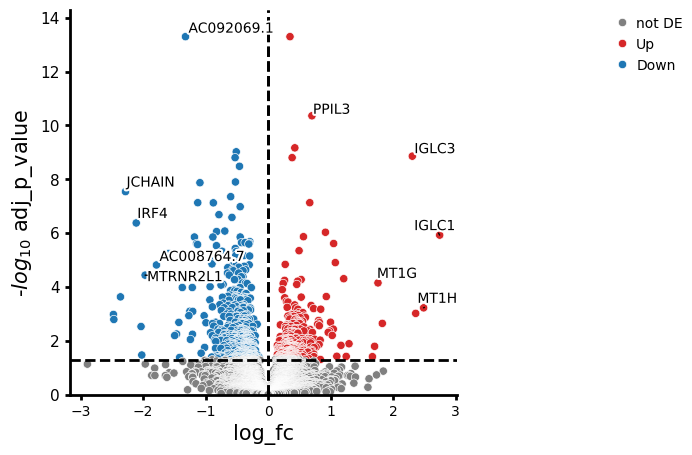

In [17]:
pds2.plot_volcano(res_df, log2fc_thresh=0)

In [23]:
pds2.dds

AnnData object with n_obs × n_vars = 223 × 26158
    obs: 'participant', 'cell_type1', 'status', 'assignment', 'sample_name', 'disease', 'tissue', 'cohort', 'cell_type', 'cd45', 'lib_name', 'sex', 'psbulk_cells', 'psbulk_counts', 'size_factors', 'replaceable'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable', 'mean', 'std', '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'log1p', 'pca', 'participant_colors', 'cohort_colors', 'cell_type_colors', 'sex_colors', 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_di

#### all cell types

In [294]:
adata_pb.X

array([[ 0.,  0.,  1., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 2.,  0.,  2., ..., 34.,  4.,  0.],
       [ 0.,  0.,  3., ...,  0.,  5.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]],
      shape=(96, 26158), dtype=float32)

In [314]:
np.isnan(pdata_ct.X).any()

np.False_

In [315]:
pdata_ct

AnnData object with n_obs × n_vars = 7 × 26158
    obs: 'participant', 'cell_type_', 'cell_type1_', 'cohort', 'sex', 'size_factors'
    var: '_normed_means', 'non_zero', '_MoM_dispersions'
    obsm: 'design_matrix'
    layers: 'normed_counts'

In [319]:
# sc.pp.filter_genes(pdata_ct, min_cells=1
sc.pp.filter_genes(pdata_ct, min_counts=10)

In [324]:
pdata_ct = adata_pb[adata_pb.obs[cell_type_col] == ct].copy()
pdata_ct.X

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(7, 26158), dtype=float32)

In [323]:
sc.pp.filter_genes(pdata_ct, min_cells=1)
print(pdata_ct.shape)
sc.pp.filter_genes(pdata_ct, min_counts=3, )
print(pdata_ct.shape)

(7, 15217)
(7, 11566)


In [326]:
# sc.pp.filter_genes(pdata_ct, min_cells=1)
# print(pdata_ct.shape)
sc.pp.filter_genes(pdata_ct, min_counts=10, )
print(pdata_ct.shape)

(7, 7882)


In [327]:
results_per_ct = {}
skipped = []

import joblib
with joblib.parallel_backend("threading"):
    for ct in sorted(adata_pb.obs[cell_type_col].unique()):
        pdata_ct = adata_pb[adata_pb.obs[cell_type_col] == ct].copy()
        
        # sc.pp.filter_genes(pdata_ct, min_cells=1)
        sc.pp.filter_genes(pdata_ct, min_counts=10)
    
        # Need both cohort levels and enough samples for sex+cohort design
        cohorts_present = pdata_ct.obs["cohort"].nunique()
        sexes_present = pdata_ct.obs["sex"].nunique()
        n = pdata_ct.n_obs
    
        if cohorts_present < 2:
            skipped.append((ct, f"n={n}, only one cohort"))
            continue
        if n < 6:
            skipped.append((ct, f"n={n}, too few samples for sex+cohort design"))
            continue
    
        design = "~sex+cohort" if sexes_present > 1 else "~cohort"
    
        # try:
        pds2_ct = pt.tl.PyDESeq2(adata=pdata_ct, design=design, n_cpus=1)
        pds2_ct.fit()
        res_ct = pds2_ct.test_contrasts(
            pds2_ct.contrast(column="cohort", baseline="Healthy", group_to_compare="Unhealthy")
        )
        res_ct["cell_type"] = ct
        results_per_ct[ct] = res_ct
        print(f"  {ct:35s}  n={n:3d}  design={design}  top gene: {res_ct.iloc[0]['variable']}  padj={res_ct.iloc[0]['adj_p_value']:.2e}")
        # except Exception as e:
            # skipped.append((ct, str(e)))

# print("\nSkipped:")
for ct, reason in skipped:
    print(f"  {ct}: {reason}")

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Traceback (most recent call last):
  File "/opt/miniconda3/envs/rnaseq/lib/python3.13/multiprocessing/resource_tracker.py", line 371, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/joblib_memmapping_folder_2446_b09450443d7044d493d22906b316935c_e04f4446639f4007a1e9e813a66aaa26 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/opt/miniconda3/envs/rnaseq/lib/python3.13/multiprocessing/resource_tracker.py", line 371, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/joblib_memmapping_folder_2446_b09450443d7044d493d22906b316935c_d9e22261bbae42d2af74f0ce4531442b for automatic cleanup: 

BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [38]:
res_df = pd.concat(results_per_ct.values(), axis=0)
res_df.sort_values("adj_p_value").head(10)

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast,cell_type
0,HSPA6,38.444346,-5.375464,0.547923,-9.810622,1.013423e-22,1.523681e-18,None,mNK2 cell
0,ITLN1,43.544401,1.650624,0.215204,7.670029,1.719569e-14,1.873814e-10,None,CD4+ T cells
0,CFD,49.232357,-1.944956,0.313384,-6.206304,5.424506e-10,1.256858e-06,None,VECs
1,GZMB,21.616105,-2.225851,0.363236,-6.127841,8.907976e-10,5.645875e-06,None,Mesothelial cells
0,LYZ,39.133890,-1.671133,0.268163,-6.231785,4.611516e-10,5.645875e-06,None,Mesothelial cells
2,IGLC2,31.910560,1.980003,0.334883,5.912514,3.369245e-09,1.423618e-05,None,Mesothelial cells
2,HLA-DRB1,209.171490,-1.303358,0.219708,-5.932221,2.988640e-09,1.459950e-05,None,FAPs
5,RPS27L,768.446549,0.717304,0.130326,5.503916,3.714456e-08,9.072559e-05,None,FAPs
6,NFASC,84.469331,-1.280264,0.241451,-5.302385,1.142998e-07,1.861181e-04,None,FAPs
3,PDZK1IP1,415.642438,0.905253,0.167549,5.402906,6.556985e-08,2.077909e-04,None,Mesothelial cells


In [40]:
alpha = 0.05

for ct, ct_results in results_per_ct.items():
    signif = ct_results.loc[ct_results["adj_p_value"] < alpha, :]
    signif_num = signif.shape[0]
    print(f"{ct}: {signif_num}")
    if signif_num:
        print(signif.sort_values("adj_p_value").head(10))
    else:
        print()
    print("------------------------------------------------------------------------")

B cells: 2
  variable    baseMean    log_fc     lfcSE      stat       p_value  \
0   SMCHD1   34.057458 -1.620803  0.307626 -5.268749  1.373564e-07   
1    RPL41  673.448309  0.398759  0.085262  4.676861  2.912997e-06   

   adj_p_value contrast cell_type  
0     0.002110     None   B cells  
1     0.022373     None   B cells  
------------------------------------------------------------------------
CD4+ T cells: 11
  variable    baseMean    log_fc     lfcSE      stat       p_value  \
0    ITLN1   43.544401  1.650624  0.215204  7.670029  1.719569e-14   
1    IGLC2   13.245078  2.109186  0.393519  5.359813  8.330805e-08   
2    RPS10  462.032728  0.438360  0.087916  4.986096  6.161140e-07   
3     MIDN   92.494913 -0.712956  0.155105 -4.596591  4.294592e-06   
4   S100A9    7.551997 -2.424150  0.554416 -4.372439  1.228664e-05   
5    NEAT1  881.309311 -0.670543  0.156175 -4.293527  1.758567e-05   
6    SYTL2   29.015163 -1.383351  0.326097 -4.242150  2.213884e-05   
7    KDM6B  127.4297

In [19]:
with pd.option_context('display.max_rows', 300):
    print(adata.obs.value_counts(["cell_type1", "cohort", "participant"]).sort_index())

cell_type1             cohort     participant        
B cells                Healthy    Omentum_Healthy_0        91
                                  Omentum_Healthy_1        12
                                  Omentum_Healthy_2       135
                                  Omentum_Healthy_3        26
                                  Omentum_Healthy_4         8
                       Unhealthy  Omentum_Unhealthy_0      24
                                  Omentum_Unhealthy_1       5
                                  Omentum_Unhealthy_2      16
                                  Omentum_Unhealthy_3      52
                                  Omentum_Unhealthy_4       5
CD4+ T cells           Healthy    Omentum_Healthy_0       309
                                  Omentum_Healthy_1       301
                                  Omentum_Healthy_2       330
                                  Omentum_Healthy_3       274
                                  Omentum_Healthy_4        74
                

In [ ]:
# Combined results table, significant hits per cell type
de_all = pd.concat(results_per_ct.values(), ignore_index=True)

sig = de_all[de_all["adj_p_value"] < 0.05].copy()
print(f"Significant DE genes (padj < 0.05): {len(sig)} across {sig['cell_type'].nunique()} cell types\n")
print(sig.groupby("cell_type")["variable"].count().rename("n_sig_genes").sort_values(ascending=False).to_string())

In [ ]:
# Inspect results for a specific cell type
ct_of_interest = "FAPs"  # change as needed
res = results_per_ct[ct_of_interest]
print(f"Top DE genes in {ct_of_interest} (Unhealthy vs Healthy):")
res.head(20)

In [ ]:
# Save all per-cell-type results
import os
os.makedirs("results/DE", exist_ok=True)

de_all.to_csv("results/DE/de_per_celltype_unhealthy_vs_healthy.csv", index=False)
sig.to_csv("results/DE/de_per_celltype_significant.csv", index=False)
print("Saved to results/DE/")

In [26]:
adata_om = sc.read_h5ad("inputs/anndatas/omentum_reannotated_finely_truncated.h5ad")
adata_sq = sc.read_h5ad("inputs/anndatas/sq_reannotated_finely_truncated.h5ad")

In [27]:
for tissue, adata in zip(["Omentum", "SubQ"],[adata_om, adata_sq]):
    print(tissue)
    print(adata.obs.value_counts("cohort"))
    print("------")

Omentum
cohort
Healthy      14574
Unhealthy    11256
Name: count, dtype: int64
------
SubQ
cohort
Unhealthy    6056
Healthy      3071
Name: count, dtype: int64
------


In [33]:
cell_type_col = "cell_type_"
res_all = pd.read_csv(f"results/DE/omentum/MAST_results_per_{cell_type_col}.csv")

In [36]:
res_all["dir"] = "up"
res_all.loc[res_all.score <0, "dir"] = "down"

In [37]:
fdr_threshold = 0.05
res_all.loc[res_all["FDR"] < fdr_threshold,:].value_counts(["cell_type", "dir"]).sort_index()

cell_type       dir 
B_cells         down     371
                up       282
ECs             down      80
                up       100
FAPs            down    2185
                up      1885
IGFBP2_cells    down     187
                up       141
Mesothelial     down    3314
                up      3381
Myeloid_cells   down     795
                up       673
Myofibroblasts  down      11
                up        19
NK_cells        down     920
                up       663
Plasma_cells    down      14
                up         8
T_cells         down    1306
                up       994
Name: count, dtype: int64